In [1]:
%load_ext autoreload

from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv("../.env")

True

In [2]:
%autoreload 2

In [3]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf

In [4]:
base = "/Users/kyledorman/data/results/estuary/train/20260305-095554/seasonal_drivers"

daily = pd.read_parquet(f"{base}/daily_driver_table.parquet")
seasonal = pd.read_parquet(f"{base}/seasonal_driver_table.parquet")
wy_seasonal = pd.read_parquet(f"{base}/wy_seasonal_driver_table.parquet")
annual = pd.read_parquet(f"{base}/annual_driver_table.parquet")

print("daily:", daily.shape)

print("seasonal:", seasonal.shape)

print("wy_seasonal:", wy_seasonal.shape)

print("annual:", annual.shape)

daily.head(3)

daily: (58160, 38)
seasonal: (640, 33)
wy_seasonal: (640, 33)
annual: (180, 32)


,region,date,p_open,p_closed,y_pred_open,entropy,entropy_norm,year,month,season,...,streamflow_mean,streamflow_median,streamflow_max,flow_n_obs,tide_mean,tide_min,tide_max,tide_range,tide_n_obs,day
0,11,2018-01-01,0.999994,0.000006,1,0.000083,0.000120,2018,1,winter,...,2.346771,2.33000,2.4325,24.0,0.032914,-1.253959,1.188744,2.442702,48,1
1,11,2018-01-02,0.999994,0.000006,1,0.000079,0.000114,2018,1,winter,...,2.407292,2.39000,2.4775,24.0,0.041546,-1.269641,1.221578,2.491219,48,2
2,11,2018-01-03,0.999994,0.000006,1,0.000075,0.000108,2018,1,winter,...,2.501667,2.48875,2.6600,24.0,0.038134,-1.253178,1.174155,2.427334,48,3


In [5]:
gdf = gpd.read_file("/Volumes/x10pro/estuary/geos/ca_data_w_empa_pmep_usgs.geojson")
gdf["region"] = gdf["Site code"]
gdf = gdf.set_index("region")

In [6]:
seasonal_ok = seasonal[seasonal["keep"]].copy()
wy_seasonal_ok = wy_seasonal[wy_seasonal["keep"]].copy()
annual_ok = annual[annual["keep"]].copy()

print("seasonal_ok:", seasonal_ok.shape)
print("wy_seasonal_ok:", wy_seasonal_ok.shape)
print("annual_ok:", annual_ok.shape)

print("\nSeasonal rows per site:")
display(
    seasonal_ok.groupby("region").size().rename("n_rows").sort_values(ascending=False).to_frame()
)

print("\nWY seasonal rows per site:")
display(
    wy_seasonal_ok.groupby("region").size().rename("n_rows").sort_values(ascending=False).to_frame()
)

print("\nAnnual rows per site:")
display(annual_ok.groupby("region").size().rename("n_rows").sort_values(ascending=False).to_frame())

seasonal_ok: (544, 33)
wy_seasonal_ok: (566, 33)
annual_ok: (136, 32)

Seasonal rows per site:


,n_rows
region,
11,28
14,28
12103,28
2138,28
96,28
92,28
84,28
57,28
56,28



WY seasonal rows per site:


,n_rows
region,
11,29
14,29
12103,29
2138,29
96,29
92,29
84,29
57,29
56,29



Annual rows per site:


,n_rows
region,
11,7
14,7
12103,7
2138,7
96,7
92,7
84,7
57,7
56,7


In [7]:
# order for plotting
season_order = ["winter", "spring", "summer", "fall"]

seasonal_clim = seasonal_ok.groupby("season", as_index=False).agg(
    mean_p_open_median=("mean_p_open", "median"),
    mean_p_open_q25=("mean_p_open", lambda s: s.quantile(0.25)),
    mean_p_open_q75=("mean_p_open", lambda s: s.quantile(0.75)),
    streamflow_mean_median=("streamflow_mean", "median"),
    streamflow_mean_q25=("streamflow_mean", lambda s: s.quantile(0.25)),
    streamflow_mean_q75=("streamflow_mean", lambda s: s.quantile(0.75)),
    wave_energy_cross_median=("wave_energy_cross_mean", "median"),
    wave_energy_cross_q25=("wave_energy_cross_mean", lambda s: s.quantile(0.25)),
    wave_energy_cross_q75=("wave_energy_cross_mean", lambda s: s.quantile(0.75)),
    tide_range_median=("tide_range_mean", "median"),
    tide_range_q25=("tide_range_mean", lambda s: s.quantile(0.25)),
    tide_range_q75=("tide_range_mean", lambda s: s.quantile(0.75)),
    n=("region", "size"),
)

seasonal_clim["season"] = pd.Categorical(
    seasonal_clim["season"],
    categories=season_order,
    ordered=True,
)
seasonal_clim = seasonal_clim.sort_values("season")

seasonal_clim

,season,mean_p_open_median,mean_p_open_q25,mean_p_open_q75,streamflow_mean_median,streamflow_mean_q25,streamflow_mean_q75,wave_energy_cross_median,wave_energy_cross_q25,wave_energy_cross_q75,tide_range_median,tide_range_q25,tide_range_q75,n
3,winter,0.873292,0.556244,0.998634,88.804165,11.712603,318.658878,29.287766,10.296594,71.680988,1.645599,1.612326,1.706553,134
1,spring,0.955177,0.567229,0.999840,51.098891,7.153089,232.978223,17.117973,10.790194,35.444284,1.628024,1.593365,1.677606,137
2,summer,0.429095,0.000699,0.999850,5.525930,0.591287,26.660116,9.711109,5.433722,14.523755,1.602977,1.573003,1.664600,136
0,fall,0.200368,0.011346,0.785080,3.574529,0.305320,10.399535,14.064468,8.017220,33.129297,1.631245,1.600922,1.682462,137


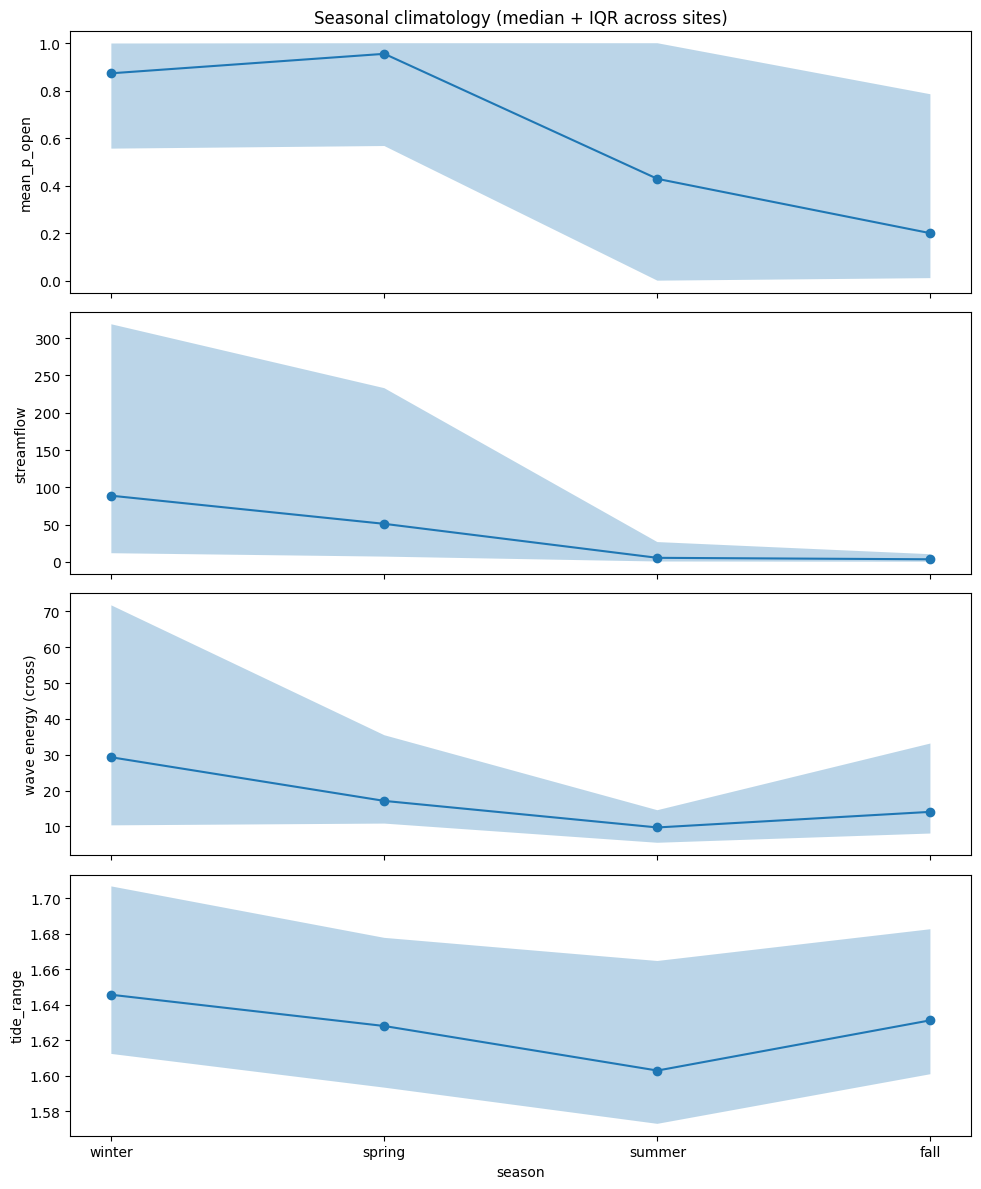

In [9]:
fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)


def plot_with_iqr(ax, x, median, q25, q75, label):
    ax.plot(x, median, marker="o", label=label)
    ax.fill_between(x, q25, q75, alpha=0.3)


# p_open
plot_with_iqr(
    axes[0],
    seasonal_clim["season"],
    seasonal_clim["mean_p_open_median"],
    seasonal_clim["mean_p_open_q25"],
    seasonal_clim["mean_p_open_q75"],
    "p_open",
)
axes[0].set_ylabel("mean_p_open")
axes[0].set_title("Seasonal climatology (median + IQR across sites)")

# flow
plot_with_iqr(
    axes[1],
    seasonal_clim["season"],
    seasonal_clim["streamflow_mean_median"],
    seasonal_clim["streamflow_mean_q25"],
    seasonal_clim["streamflow_mean_q75"],
    "streamflow",
)
axes[1].set_ylabel("streamflow")

# waves (cross-shore only for clarity)
plot_with_iqr(
    axes[2],
    seasonal_clim["season"],
    seasonal_clim["wave_energy_cross_median"],
    seasonal_clim["wave_energy_cross_q25"],
    seasonal_clim["wave_energy_cross_q75"],
    "wave_cross",
)
axes[2].set_ylabel("wave energy (cross)")

# tide
plot_with_iqr(
    axes[3],
    seasonal_clim["season"],
    seasonal_clim["tide_range_median"],
    seasonal_clim["tide_range_q25"],
    seasonal_clim["tide_range_q75"],
    "tide_range",
)
axes[3].set_ylabel("tide_range")
axes[3].set_xlabel("season")

plt.tight_layout()
plt.savefig("/Users/kyledorman/Desktop/seasonal_driver_trends.png")
plt.show()

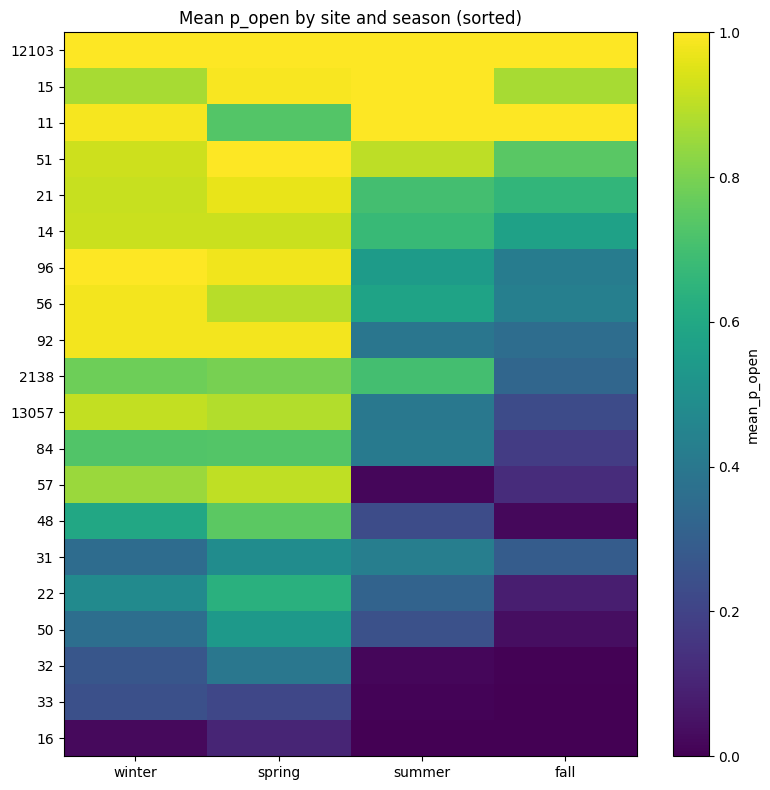

In [10]:
site_season_mat = seasonal_ok.pivot_table(
    index="region",
    columns="season",
    values="mean_p_open",
    aggfunc="mean",
).reindex(columns=["winter", "spring", "summer", "fall"])

site_season_mat_sorted = site_season_mat.loc[
    site_season_mat.mean(axis=1).sort_values(ascending=False).index
]

fig, ax = plt.subplots(figsize=(8, 8))

im = ax.imshow(site_season_mat_sorted.values, aspect="auto", vmin=0, vmax=1)

ax.set_xticks(range(site_season_mat_sorted.shape[1]))
ax.set_xticklabels(site_season_mat_sorted.columns)

ax.set_yticks(range(site_season_mat_sorted.shape[0]))
ax.set_yticklabels(site_season_mat_sorted.index)

ax.set_title("Mean p_open by site and season (sorted)")

plt.colorbar(im, ax=ax, label="mean_p_open")
plt.tight_layout()
plt.show()

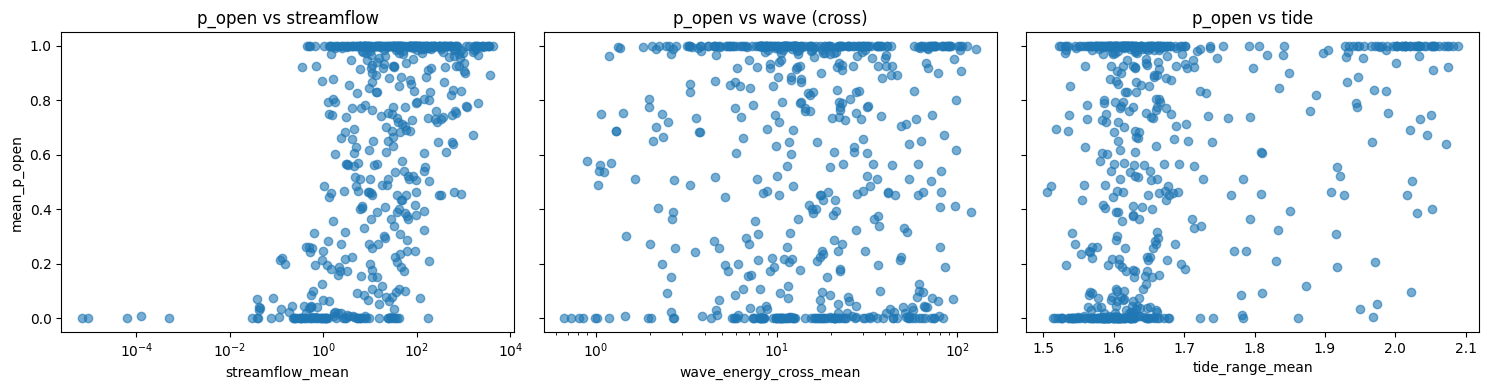

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

# Flow
axes[0].scatter(
    wy_seasonal_ok["streamflow_mean"],
    wy_seasonal_ok["mean_p_open"],
    alpha=0.6,
)
axes[0].set_xscale("log")
axes[0].set_xlabel("streamflow_mean")
axes[0].set_ylabel("mean_p_open")
axes[0].set_title("p_open vs streamflow")

# Wave (cross-shore is the important one)
axes[1].scatter(
    wy_seasonal_ok["wave_energy_cross_mean"],
    wy_seasonal_ok["mean_p_open"],
    alpha=0.6,
)
axes[1].set_xscale("log")
axes[1].set_xlabel("wave_energy_cross_mean")
axes[1].set_title("p_open vs wave (cross)")

# Tide
axes[2].scatter(
    wy_seasonal_ok["tide_range_mean"],
    wy_seasonal_ok["mean_p_open"],
    alpha=0.6,
)
axes[2].set_xlabel("tide_range_mean")
axes[2].set_title("p_open vs tide")

plt.tight_layout()
plt.savefig("/Users/kyledorman/Desktop/drivers_v_open.png")
plt.show()

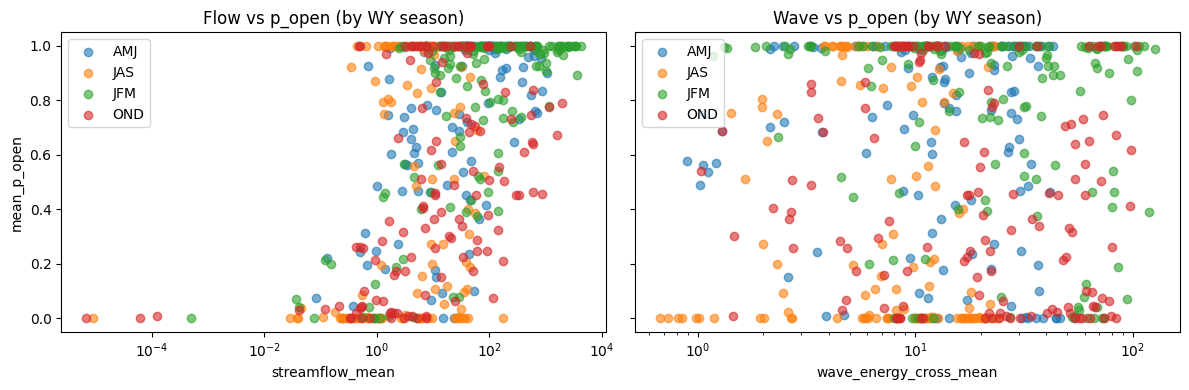

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for season, sub in wy_seasonal_ok.groupby("wy_season"):
    axes[0].scatter(
        sub["streamflow_mean"],
        sub["mean_p_open"],
        label=season,
        alpha=0.6,
    )

axes[0].set_xscale("log")
axes[0].set_xlabel("streamflow_mean")
axes[0].set_ylabel("mean_p_open")
axes[0].set_title("Flow vs p_open (by WY season)")
axes[0].legend()

for season, sub in wy_seasonal_ok.groupby("wy_season"):
    axes[1].scatter(
        sub["wave_energy_cross_mean"],
        sub["mean_p_open"],
        label=season,
        alpha=0.6,
    )

axes[1].set_xscale("log")
axes[1].set_xlabel("wave_energy_cross_mean")
axes[1].set_title("Wave vs p_open (by WY season)")
axes[1].legend()

plt.tight_layout()
plt.savefig("/Users/kyledorman/Desktop/drivers_v_open_season.png")
plt.show()

# Seasonal Annomolies
Drivers are not well captured by the seasonal averages alone. 

In [15]:
anom_cols = [
    "mean_p_open",
    "streamflow_max",
    "wave_energy_cross_mean",
    "wave_energy_mean",
    "tide_range_mean",
]


def add_anomalies(df, group_cols, cols):
    out = df.copy()

    clim = (
        out.groupby(group_cols, as_index=False)[cols]
        .mean()
        .rename(columns={c: f"{c}_clim" for c in cols})
    )

    out = out.merge(clim, on=group_cols, how="left")

    for c in cols:
        out[f"{c}_anom"] = out[c] - out[f"{c}_clim"]

    return out


wy_anom = add_anomalies(
    wy_seasonal_ok,
    group_cols=["region", "wy_season"],
    cols=anom_cols,
)

wy_anom.head()

,region,water_year,wy_season,start_date,end_date,n_days,mean_p_open,mean_p_closed,mean_entropy,wave_hs_mean,...,mean_p_open_clim,streamflow_max_clim,wave_energy_cross_mean_clim,wave_energy_mean_clim,tide_range_mean_clim,mean_p_open_anom,streamflow_max_anom,wave_energy_cross_mean_anom,wave_energy_mean_anom,tide_range_mean_anom
0,11,2018,AMJ,2018-04-01,2018-06-30,91,0.748256,0.251744,0.163201,0.895208,...,0.750285,581.616429,9.199253,9.480817,1.568133,-0.002028,-573.551429,0.590069,0.560607,-0.032076
1,11,2018,JAS,2018-07-01,2018-09-30,92,0.999992,0.000008,0.000140,0.655744,...,0.999993,115.203571,5.363226,5.642675,1.590080,-0.000001,-113.663571,-0.024117,-0.020482,-0.058220
2,11,2018,JFM,2018-01-01,2018-03-31,90,0.980593,0.019407,0.070889,0.912195,...,0.968368,1451.406250,15.408959,15.541726,1.621244,0.012225,-443.906250,-2.482625,-2.467687,-0.015067
3,11,2019,AMJ,2019-04-01,2019-06-30,91,0.693512,0.306488,0.232466,0.771252,...,0.750285,581.616429,9.199253,9.480817,1.568133,-0.056772,-478.616429,-0.372214,-0.375458,-0.049783
4,11,2019,JAS,2019-07-01,2019-09-30,92,0.999995,0.000005,0.000085,0.683743,...,0.999993,115.203571,5.363226,5.642675,1.590080,0.000002,-106.213571,1.382591,1.483290,0.006683


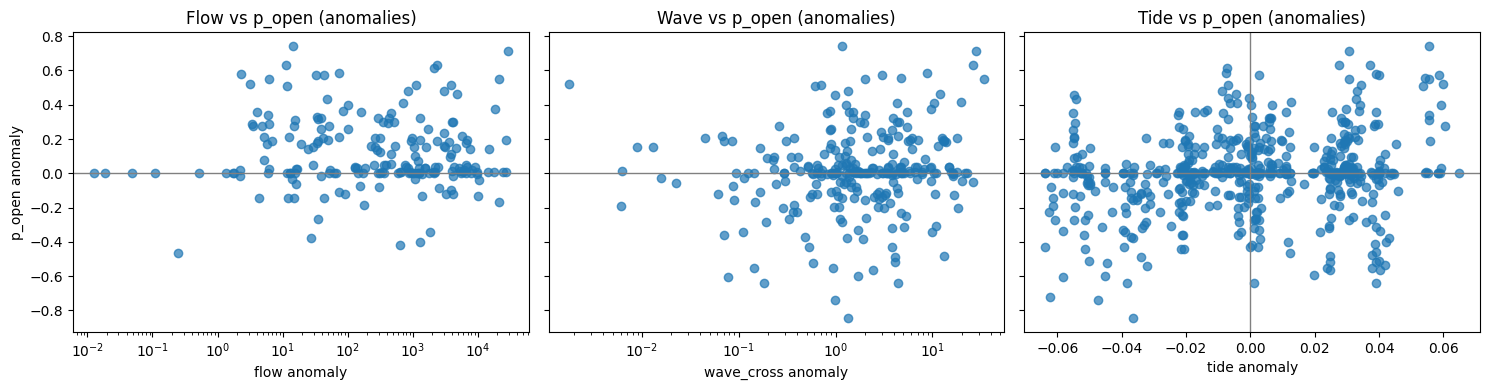

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

# Flow anomaly
axes[0].scatter(
    wy_anom["streamflow_max_anom"],
    wy_anom["mean_p_open_anom"],
    alpha=0.7,
)
axes[0].axhline(0, color="gray", lw=1)
axes[0].axvline(0, color="gray", lw=1)
axes[0].set_xscale("log")
axes[0].set_xlabel("flow anomaly")
axes[0].set_ylabel("p_open anomaly")
axes[0].set_title("Flow vs p_open (anomalies)")

# Wave anomaly
axes[1].scatter(
    wy_anom["wave_energy_cross_mean_anom"],
    wy_anom["mean_p_open_anom"],
    alpha=0.7,
)
axes[1].axhline(0, color="gray", lw=1)
axes[1].axvline(0, color="gray", lw=1)
axes[1].set_xscale("log")
axes[1].set_xlabel("wave_cross anomaly")
axes[1].set_title("Wave vs p_open (anomalies)")

# Combined view later, keep tide simple
axes[2].scatter(
    wy_anom["tide_range_mean_anom"],
    wy_anom["mean_p_open_anom"],
    alpha=0.7,
)
axes[2].axhline(0, color="gray", lw=1)
axes[2].axvline(0, color="gray", lw=1)
axes[2].set_xlabel("tide anomaly")
axes[2].set_title("Tide vs p_open (anomalies)")

plt.tight_layout()
plt.savefig("/Users/kyledorman/Desktop/drivers_anom.png")
plt.show()

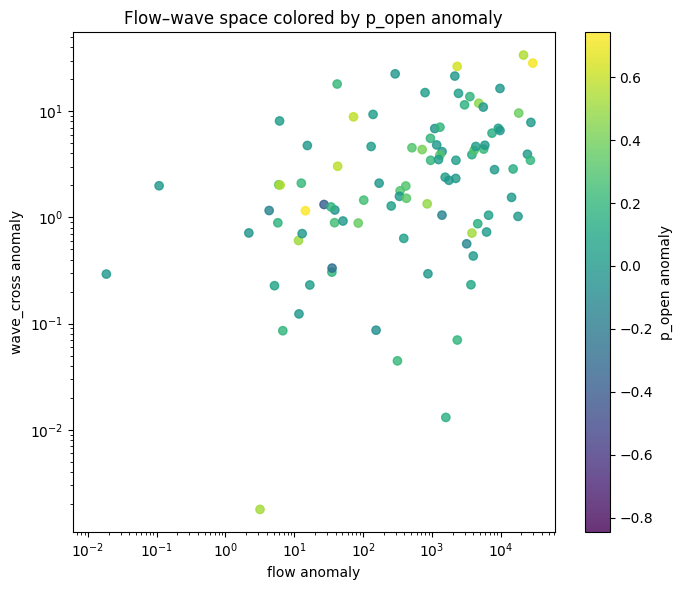

In [18]:
fig, ax = plt.subplots(figsize=(7, 6))

sc = ax.scatter(
    wy_anom["streamflow_max_anom"],
    wy_anom["wave_energy_cross_mean_anom"],
    c=wy_anom["mean_p_open_anom"],
    alpha=0.8,
)

ax.axhline(0, color="gray", lw=1)
ax.axvline(0, color="gray", lw=1)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("flow anomaly")
ax.set_ylabel("wave_cross anomaly")
ax.set_title("Flow–wave space colored by p_open anomaly")

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("p_open anomaly")

plt.tight_layout()
plt.show()

# Monthly Annomolies

In [19]:
monthly = pd.read_parquet(f"{base}/monthly_driver_table.parquet")
monthly_ok = monthly[monthly["keep"]].copy()

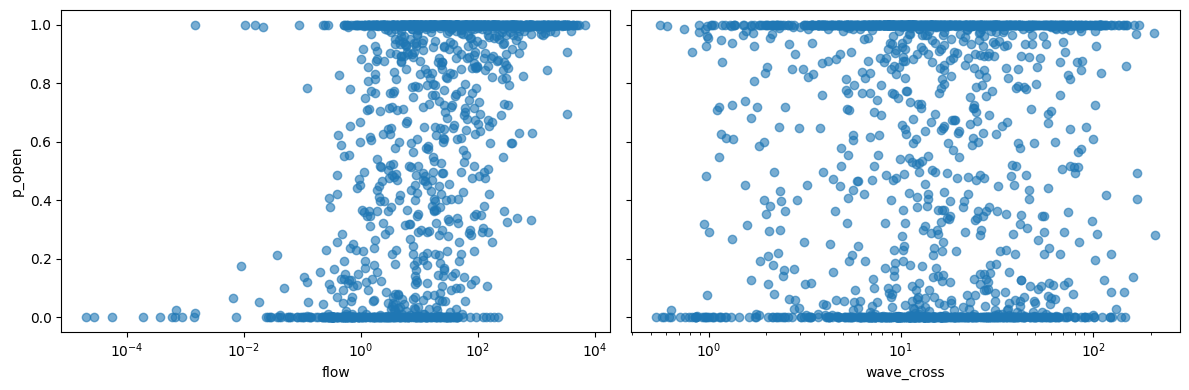

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].scatter(
    monthly_ok["streamflow_mean"],
    monthly_ok["mean_p_open"],
    alpha=0.6,
)
axes[0].set_xscale("log")
axes[0].set_xlabel("flow")
axes[0].set_ylabel("p_open")

axes[1].scatter(
    monthly_ok["wave_energy_cross_mean"],
    monthly_ok["mean_p_open"],
    alpha=0.6,
)
axes[1].set_xscale("log")
axes[1].set_xlabel("wave_cross")

plt.tight_layout()
plt.show()

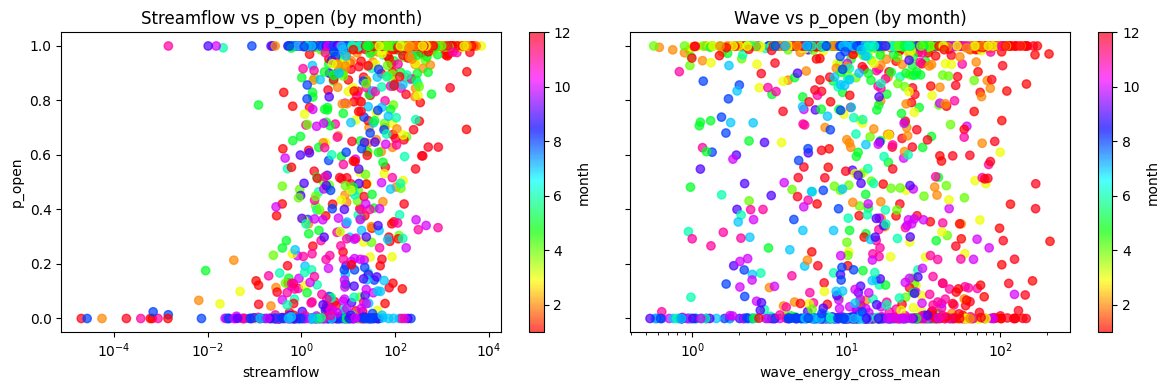

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

sc = axes[0].scatter(
    monthly_ok["streamflow_mean"],
    monthly_ok["mean_p_open"],
    c=monthly_ok["month"],
    cmap="hsv",
    alpha=0.7,
)

axes[0].set_xscale("log")
axes[0].set_xlabel("streamflow")
axes[0].set_ylabel("p_open")
axes[0].set_title("Streamflow vs p_open (by month)")
cbar = plt.colorbar(sc, ax=axes[0])
cbar.set_label("month")

sc = axes[1].scatter(
    monthly_ok["wave_energy_cross_mean"],
    monthly_ok["mean_p_open"],
    c=monthly_ok["month"],
    cmap="hsv",
    alpha=0.7,
)

axes[1].set_xscale("log")
axes[1].set_xlabel("wave_energy_cross_mean")
axes[1].set_title("Wave vs p_open (by month)")
cbar = plt.colorbar(sc, ax=axes[1])
cbar.set_label("month")

plt.tight_layout()
plt.show()

In [22]:
anom_cols = [
    "mean_p_open",
    "streamflow_max",
    "wave_energy_cross_p90",
    "tide_range_mean",
]


def add_anomalies(df, group_cols, cols):
    out = df.copy()

    clim = (
        out.groupby(group_cols, as_index=False)[cols]
        .mean()
        .rename(columns={c: f"{c}_clim" for c in cols})
    )

    out = out.merge(clim, on=group_cols, how="left")

    for c in cols:
        out[f"{c}_anom"] = out[c] - out[f"{c}_clim"]

    return out


month_anom = add_anomalies(
    monthly_ok,
    group_cols=["region", "month"],
    cols=anom_cols,
)

month_anom.head()

,region,year,month,start_date,end_date,n_days,mean_p_open,mean_p_closed,mean_entropy,wave_hs_mean,...,wy_season,keep,mean_p_open_clim,streamflow_max_clim,wave_energy_cross_p90_clim,tide_range_mean_clim,mean_p_open_anom,streamflow_max_anom,wave_energy_cross_p90_anom,tide_range_mean_anom
0,11,2018,1,2018-01-01,2018-01-31,31,0.944131,0.055869,0.201715,1.095739,...,JFM,True,0.992633,721.718750,26.256505,1.624624,-0.048502,285.781250,0.242867,0.030503
1,11,2018,2,2018-02-01,2018-02-28,28,0.999995,0.000005,0.000090,0.805579,...,JFM,True,0.970836,889.578125,18.207715,1.618548,0.029159,-770.828125,-5.385178,-0.049285
2,11,2018,3,2018-03-01,2018-03-31,31,0.999531,0.000469,0.004010,0.824949,...,JFM,True,0.941872,647.475000,17.808776,1.620084,0.057659,-490.725000,-6.691366,-0.029515
3,11,2018,4,2018-04-01,2018-04-30,30,0.412740,0.587260,0.272721,0.954842,...,AMJ,True,0.564983,568.927143,13.685183,1.601595,-0.152243,-564.237143,2.118690,-0.054663
4,11,2018,5,2018-05-01,2018-05-31,31,0.829778,0.170222,0.210831,0.930309,...,AMJ,True,0.688033,26.609286,13.204168,1.565853,0.141745,-18.544286,-0.927150,-0.021258


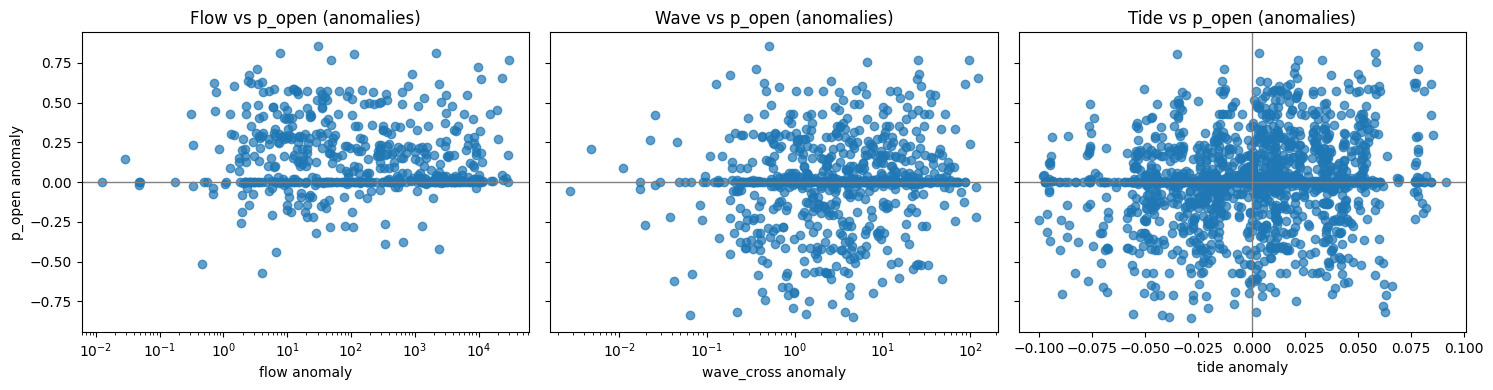

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

# Flow anomaly
axes[0].scatter(
    month_anom["streamflow_max_anom"],
    month_anom["mean_p_open_anom"],
    alpha=0.7,
)
axes[0].axhline(0, color="gray", lw=1)
axes[0].axvline(0, color="gray", lw=1)
axes[0].set_xscale("log")
axes[0].set_xlabel("flow anomaly")
axes[0].set_ylabel("p_open anomaly")
axes[0].set_title("Flow vs p_open (anomalies)")

# Wave anomaly
axes[1].scatter(
    month_anom["wave_energy_cross_p90_anom"],
    month_anom["mean_p_open_anom"],
    alpha=0.7,
)
axes[1].axhline(0, color="gray", lw=1)
axes[1].axvline(0, color="gray", lw=1)
axes[1].set_xscale("log")
axes[1].set_xlabel("wave_cross anomaly")
axes[1].set_title("Wave vs p_open (anomalies)")

# Combined view later, keep tide simple
axes[2].scatter(
    month_anom["tide_range_mean_anom"],
    month_anom["mean_p_open_anom"],
    alpha=0.7,
)
axes[2].axhline(0, color="gray", lw=1)
axes[2].axvline(0, color="gray", lw=1)
axes[2].set_xlabel("tide anomaly")
axes[2].set_title("Tide vs p_open (anomalies)")

plt.tight_layout()
plt.show()

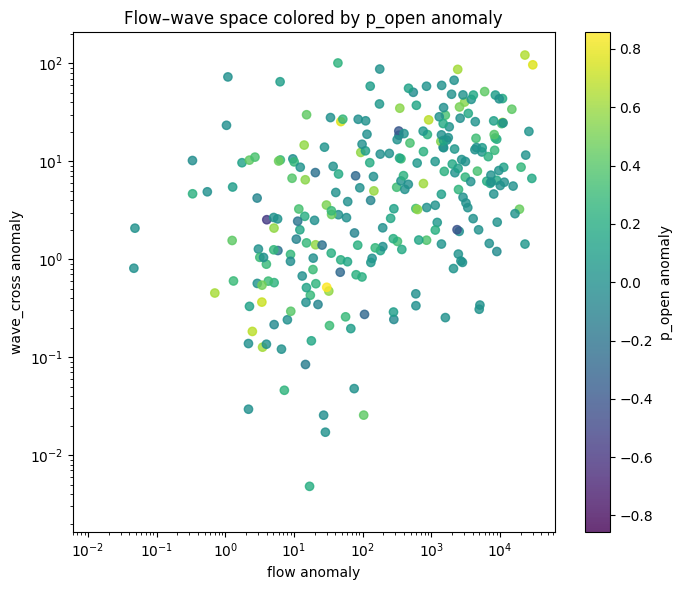

In [24]:
fig, ax = plt.subplots(figsize=(7, 6))

sc = ax.scatter(
    month_anom["streamflow_max_anom"],
    month_anom["wave_energy_cross_p90_anom"],
    c=month_anom["mean_p_open_anom"],
    alpha=0.8,
)

ax.axhline(0, color="gray", lw=1)
ax.axvline(0, color="gray", lw=1)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("flow anomaly")
ax.set_ylabel("wave_cross anomaly")
ax.set_title("Flow–wave space colored by p_open anomaly")

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("p_open anomaly")

plt.tight_layout()
plt.show()

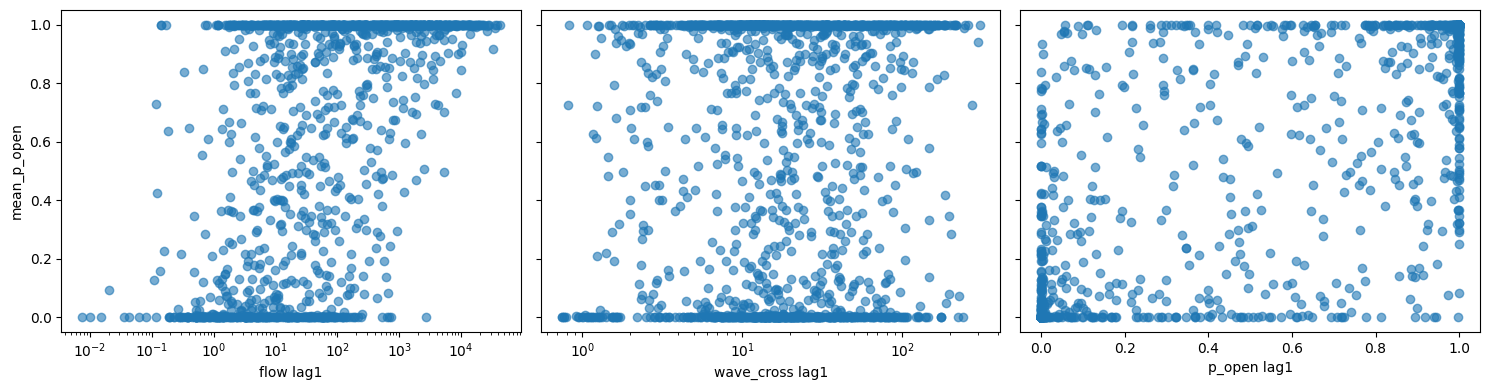

In [25]:
monthly_ok = monthly[monthly["keep"]].copy()
monthly_ok = monthly_ok.sort_values(["region", "year", "month"]).reset_index(drop=True)
monthly_ok["delta_p_open"] = monthly_ok.groupby("region")["mean_p_open"].diff()

lag_cols = [
    "mean_p_open",
    "streamflow_mean",
    "streamflow_max",
    "wave_energy_cross_mean",
    "wave_energy_cross_p90",
    "wave_energy_along_mean",
    "tide_range_mean",
]

for col in lag_cols:
    monthly_ok[f"{col}_lag1"] = monthly_ok.groupby("region")[col].shift(1)
    monthly_ok[f"{col}_lag2"] = monthly_ok.groupby("region")[col].shift(2)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

axes[0].scatter(monthly_ok["streamflow_max_lag1"], monthly_ok["mean_p_open"], alpha=0.6)
axes[0].set_xscale("log")
axes[0].set_xlabel("flow lag1")
axes[0].set_ylabel("mean_p_open")

axes[1].scatter(monthly_ok["wave_energy_cross_p90_lag1"], monthly_ok["mean_p_open"], alpha=0.6)
axes[1].set_xscale("log")
axes[1].set_xlabel("wave_cross lag1")

axes[2].scatter(monthly_ok["mean_p_open_lag1"], monthly_ok["mean_p_open"], alpha=0.6)
axes[2].set_xlabel("p_open lag1")

plt.tight_layout()
plt.show()

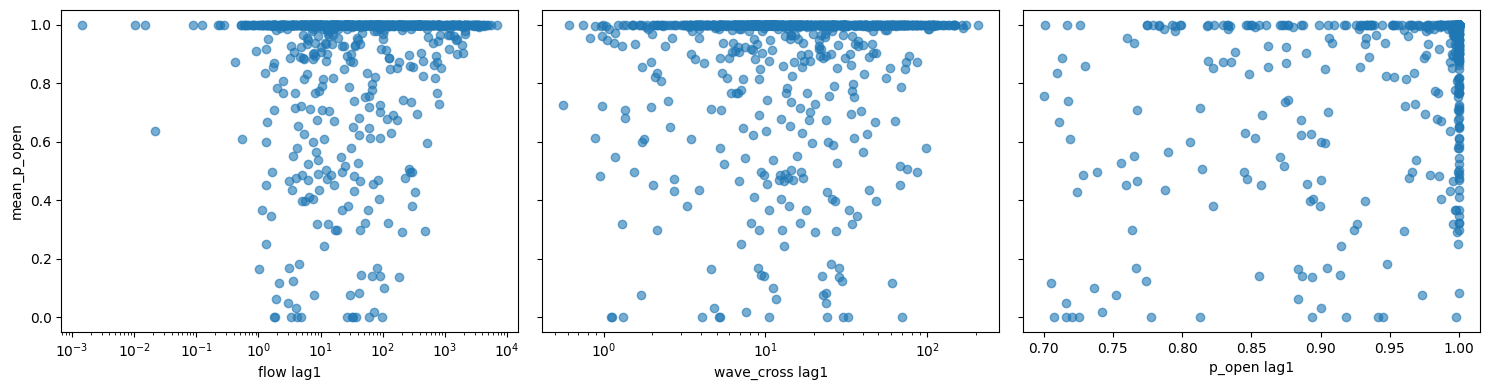

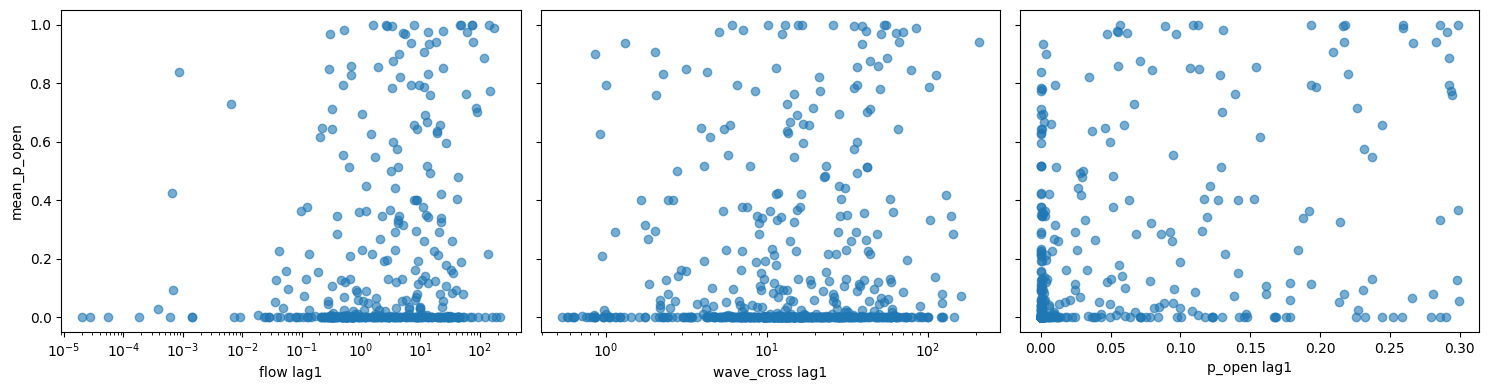

In [26]:
monthly_ok["delta_p_open"] = monthly_ok.groupby("region")["mean_p_open"].diff()
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

A = monthly_ok[monthly_ok.mean_p_open_lag1 > 0.7]

axes[0].scatter(A["streamflow_mean_lag1"], A["mean_p_open"], alpha=0.6)
axes[0].set_xscale("log")
axes[0].set_xlabel("flow lag1")
axes[0].set_ylabel("mean_p_open")

axes[1].scatter(A["wave_energy_cross_mean_lag1"], A["mean_p_open"], alpha=0.6)
axes[1].set_xscale("log")
axes[1].set_xlabel("wave_cross lag1")

axes[2].scatter(A["mean_p_open_lag1"], A["mean_p_open"], alpha=0.6)
axes[2].set_xlabel("p_open lag1")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

A = monthly_ok[monthly_ok.mean_p_open_lag1 < 0.3]

axes[0].scatter(A["streamflow_mean_lag1"], A["mean_p_open"], alpha=0.6)
axes[0].set_xscale("log")
axes[0].set_xlabel("flow lag1")
axes[0].set_ylabel("mean_p_open")

axes[1].scatter(A["wave_energy_cross_mean_lag1"], A["mean_p_open"], alpha=0.6)
axes[1].set_xscale("log")
axes[1].set_xlabel("wave_cross lag1")

axes[2].scatter(A["mean_p_open_lag1"], A["mean_p_open"], alpha=0.6)
axes[2].set_xlabel("p_open lag1")

plt.tight_layout()
plt.show()

<Axes: xlabel='start_date', ylabel='delta_p_open'>

<Figure size 640x480 with 0 Axes>

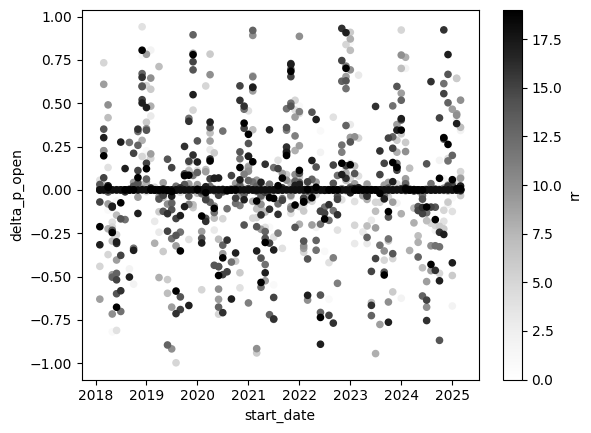

In [27]:
plt.figure()
A = monthly_ok.copy()
B = A.region.unique().tolist()
A["rr"] = A.region.apply(lambda r: B.index(r))
A.plot.scatter(x="start_date", y="delta_p_open", c="rr")

In [28]:
site_rows = []


for region, sub in monthly_ok.groupby("region"):
    sub = sub.dropna(
        subset=[
            "delta_p_open",
            "streamflow_max_lag1",
            "wave_energy_cross_p90_lag1",
        ]
    )

    if len(sub) < 6:
        continue

    flow_r = sub["delta_p_open"].corr(sub["streamflow_max_lag1"], method="spearman")
    wave_r = sub["delta_p_open"].corr(sub["wave_energy_cross_p90_lag1"], method="spearman")
    state_r = sub["delta_p_open"].corr(sub["mean_p_open_lag1"], method="spearman")

    site_rows.append(
        {
            "region": region,
            "n": len(sub),
            "rho_flow": flow_r,
            "rho_wave": wave_r,
            "rho_state": state_r,
        }
    )

site_corr = pd.DataFrame(site_rows).sort_values("region")
site_corr

,region,n,rho_flow,rho_wave,rho_state
0,11,86,-0.232266,0.021124,-0.383499
1,14,86,0.127666,-0.291665,-0.230888
2,15,84,0.142514,0.176207,-0.358206
3,16,68,-0.175497,-0.198687,-0.354354
4,21,84,0.165961,0.129594,-0.326172
5,22,84,-0.037422,0.125787,-0.315116
6,31,86,0.041733,0.129676,-0.252323
7,32,82,-0.026753,0.185185,-0.432962
8,33,85,-0.168401,0.043639,-0.410475
9,48,86,-0.074356,0.214755,-0.290985


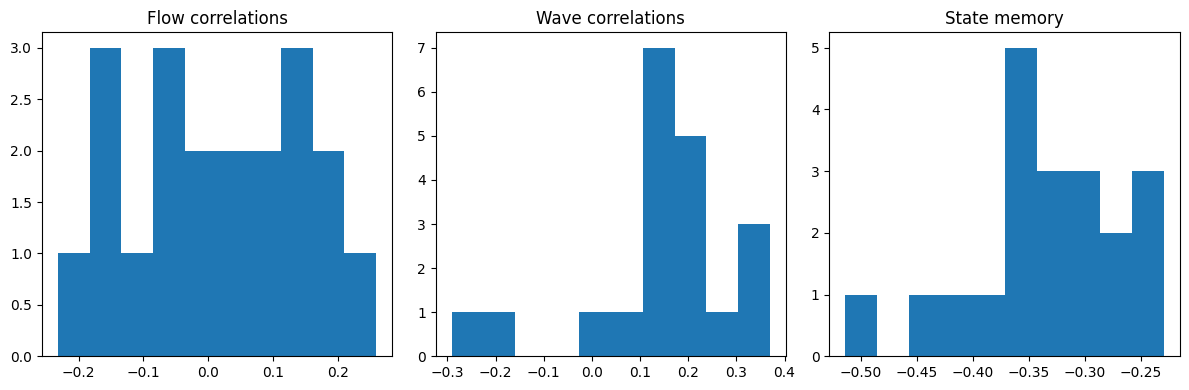

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].hist(site_corr["rho_flow"].dropna(), bins=10)
axes[0].set_title("Flow correlations")

axes[1].hist(site_corr["rho_wave"].dropna(), bins=10)
axes[1].set_title("Wave correlations")

axes[2].hist(site_corr["rho_state"].dropna(), bins=10)
axes[2].set_title("State memory")

plt.tight_layout()
plt.show()

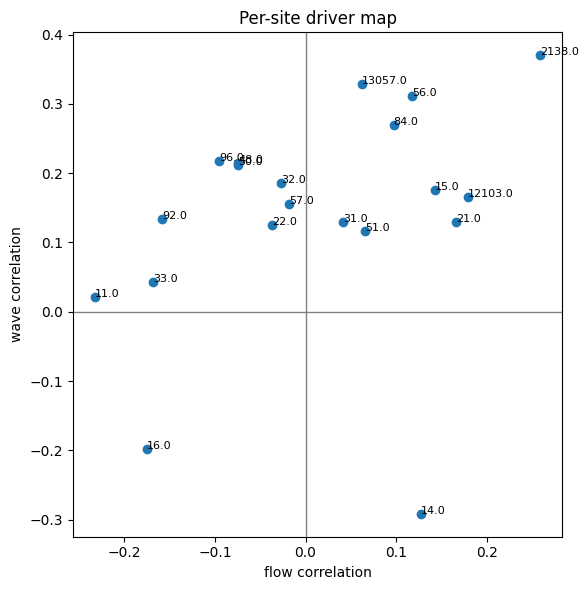

In [30]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(site_corr["rho_flow"], site_corr["rho_wave"])

for _, row in site_corr.iterrows():
    ax.text(row["rho_flow"], row["rho_wave"], str(row["region"]), fontsize=8)

ax.axhline(0, color="gray", lw=1)
ax.axvline(0, color="gray", lw=1)

ax.set_xlabel("flow correlation")
ax.set_ylabel("wave correlation")
ax.set_title("Per-site driver map")

plt.tight_layout()
plt.show()

opening: 166
closing: 165
inactive: 1366


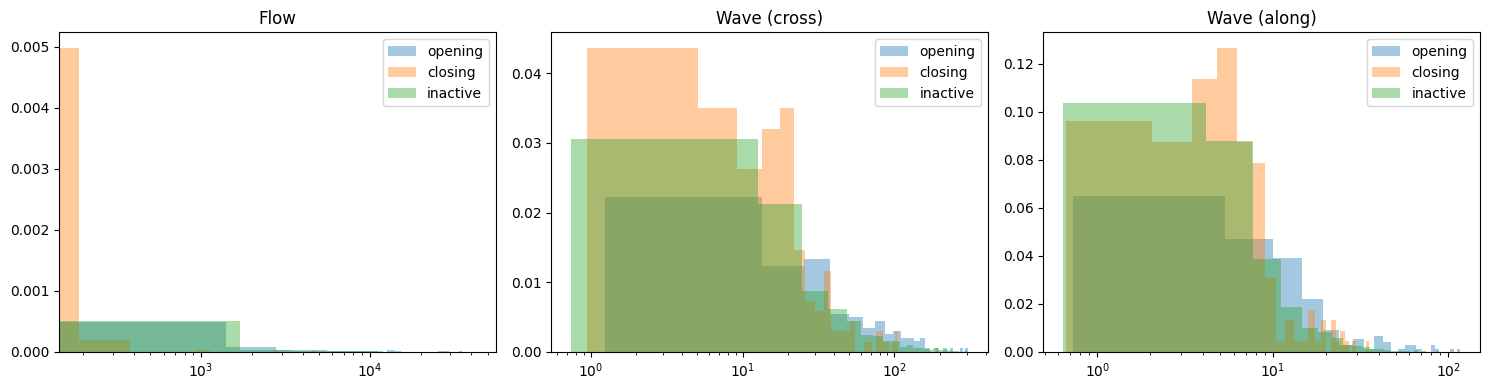

In [31]:
threshold = 0.25

monthly_ok["is_opening"] = monthly_ok["delta_p_open"] > threshold
monthly_ok["is_closing"] = monthly_ok["delta_p_open"] < -threshold
monthly_ok["is_inactive"] = ~(monthly_ok["is_opening"] | monthly_ok["is_closing"])
monthly_ok["wave_flow_ratio"] = np.log10(monthly_ok["wave_energy_cross_p90"] + 1e-6) - np.log10(
    monthly_ok["streamflow_max"] + 1e-3
)

opening = monthly_ok[monthly_ok["is_opening"]]
closing = monthly_ok[monthly_ok["is_closing"]]
inactive = monthly_ok[monthly_ok["is_inactive"]]

print("opening:", len(opening))
print("closing:", len(closing))
print("inactive:", len(inactive))


fig, axes = plt.subplots(1, 3, figsize=(15, 4))


def plot_hist(ax, data_dict, col, title):
    for label, df in data_dict.items():
        vals = df[col].dropna()
        if len(vals) == 0:
            continue
        ax.hist(
            vals,
            bins=25,
            density=True,  # KEY FIX
            alpha=0.4,
            label=label,
        )
    ax.set_xscale("log")
    ax.set_title(title)
    ax.legend()


plot_hist(
    axes[0],
    {"opening": opening, "closing": closing, "inactive": inactive},
    "streamflow_max",
    "Flow",
)

plot_hist(
    axes[1],
    {"opening": opening, "closing": closing, "inactive": inactive},
    "wave_energy_cross_p90",
    "Wave (cross)",
)

plot_hist(
    axes[2],
    {"opening": opening, "closing": closing, "inactive": inactive},
    "wave_energy_along_p90",
    "Wave (along)",
)

plt.tight_layout()
plt.show()

In [32]:
flow_thresh = monthly_ok["streamflow_max"].median()

low_flow = monthly_ok["streamflow_max"] < flow_thresh
high_flow = monthly_ok["streamflow_max"] >= flow_thresh

closing_low = closing[closing["streamflow_max"] < flow_thresh]
closing_high = closing[closing["streamflow_max"] >= flow_thresh]

opening_low = opening[opening["streamflow_max"] < flow_thresh]
opening_high = opening[opening["streamflow_max"] >= flow_thresh]

print(len(opening_high), len(opening_low))
print(len(closing_high), len(closing_low))

137 29
56 109


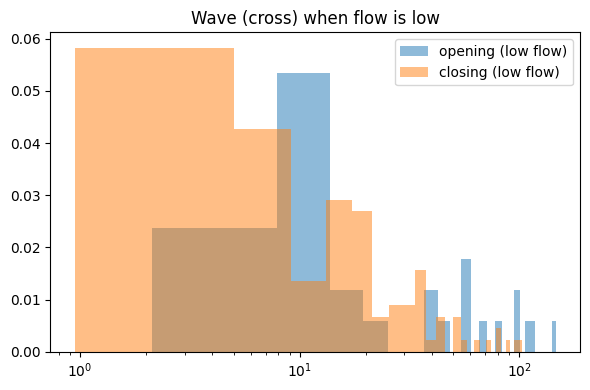

In [33]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(
    opening_low["wave_energy_cross_p90"],
    bins=25,
    density=True,
    alpha=0.5,
    label="opening (low flow)",
)

ax.hist(
    closing_low["wave_energy_cross_p90"],
    bins=25,
    density=True,
    alpha=0.5,
    label="closing (low flow)",
)

ax.set_xscale("log")
ax.set_title("Wave (cross) when flow is low")
ax.legend()

plt.tight_layout()
plt.show()

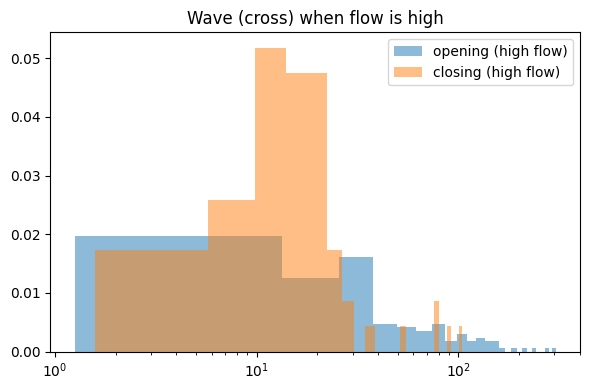

In [34]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(
    opening_high["wave_energy_cross_p90"],
    bins=25,
    density=True,
    alpha=0.5,
    label="opening (high flow)",
)

ax.hist(
    closing_high["wave_energy_cross_p90"],
    bins=25,
    density=True,
    alpha=0.5,
    label="closing (high flow)",
)

ax.set_xscale("log")
ax.set_title("Wave (cross) when flow is high")
ax.legend()

plt.tight_layout()
plt.show()

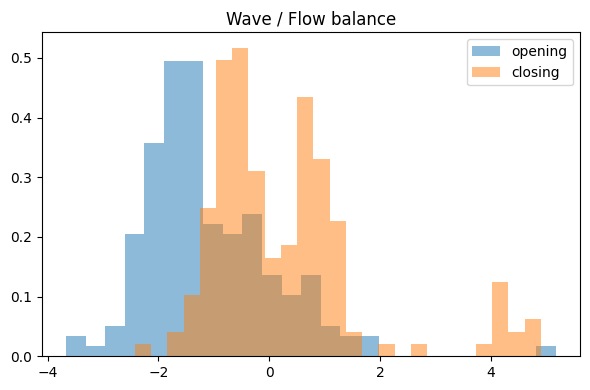

In [35]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(
    opening["wave_flow_ratio"],
    bins=25,
    density=True,
    alpha=0.5,
    label="opening",
)

ax.hist(
    closing["wave_flow_ratio"],
    bins=25,
    density=True,
    alpha=0.5,
    label="closing",
)

ax.set_title("Wave / Flow balance")
ax.legend()

plt.tight_layout()
plt.show()

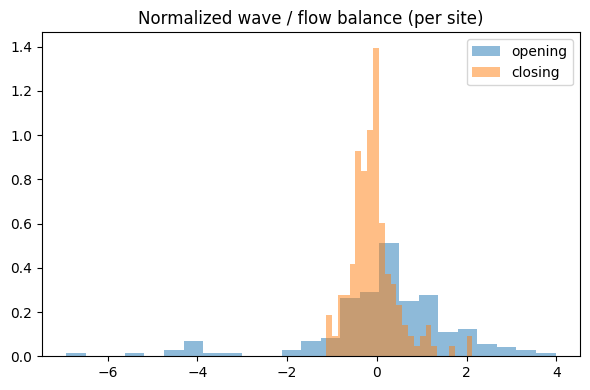

In [36]:
def zscore_by_site(df, cols):
    out = df.copy()
    for col in cols:
        mu = out.groupby("region")[col].transform("mean")
        sd = out.groupby("region")[col].transform("std")
        out[f"z_{col}"] = (out[col] - mu) / sd
    return out


monthly_z = zscore_by_site(
    monthly_ok,
    [
        "streamflow_max",
        "wave_energy_cross_p90",
    ],
)
monthly_z["wave_flow_z"] = monthly_z["z_wave_energy_cross_p90"] - monthly_z["z_streamflow_max"]
fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(
    monthly_z.loc[monthly_z["is_opening"], "wave_flow_z"],
    bins=25,
    density=True,
    alpha=0.5,
    label="opening",
)

ax.hist(
    monthly_z.loc[monthly_z["is_closing"], "wave_flow_z"],
    bins=25,
    density=True,
    alpha=0.5,
    label="closing",
)

ax.set_title("Normalized wave / flow balance (per site)")
ax.legend()

plt.tight_layout()
plt.show()

In [37]:
a = monthly_z[monthly_z["is_opening"] & (monthly_z["wave_flow_z"] > 2)].sort_values("start_date")[
    ["region", "start_date", "z_streamflow_max", "z_wave_energy_cross_p90"]
]
display(a)
a.to_markdown()

,region,start_date,z_streamflow_max,z_wave_energy_cross_p90
1447,2138,2018-12-01,-0.361267,1.795914
1621,13057,2018-12-01,-0.389309,1.912161
1645,13057,2020-12-01,-0.396649,1.700079
362,21,2021-01-01,-0.297582,2.692726
447,22,2021-01-01,-0.243918,1.881913
1211,84,2021-01-01,-0.321554,3.071651
1646,13057,2021-01-01,-0.080917,2.816298
147,14,2023-01-01,1.379768,3.970568
1235,84,2023-01-01,2.024554,4.244813
569,31,2023-12-01,-0.235514,2.987437


'|      |   region | start_date          |   z_streamflow_max |   z_wave_energy_cross_p90 |\n|-----:|---------:|:--------------------|-------------------:|--------------------------:|\n| 1447 |     2138 | 2018-12-01 00:00:00 |         -0.361267  |                   1.79591 |\n| 1621 |    13057 | 2018-12-01 00:00:00 |         -0.389309  |                   1.91216 |\n| 1645 |    13057 | 2020-12-01 00:00:00 |         -0.396649  |                   1.70008 |\n|  362 |       21 | 2021-01-01 00:00:00 |         -0.297582  |                   2.69273 |\n|  447 |       22 | 2021-01-01 00:00:00 |         -0.243918  |                   1.88191 |\n| 1211 |       84 | 2021-01-01 00:00:00 |         -0.321554  |                   3.07165 |\n| 1646 |    13057 | 2021-01-01 00:00:00 |         -0.080917  |                   2.8163  |\n|  147 |       14 | 2023-01-01 00:00:00 |          1.37977   |                   3.97057 |\n| 1235 |       84 | 2023-01-01 00:00:00 |          2.02455   |                 

In [38]:
monthly_z.columns

Index(['region', 'year', 'month', 'start_date', 'end_date', 'n_days',
       'mean_p_open', 'mean_p_closed', 'mean_entropy', 'wave_hs_mean',
       'wave_hs_p90', 'wave_tp_mean', 'wave_tp_p90', 'wave_energy_mean',
       'wave_energy_p90', 'wave_energy_max', 'wave_energy_cross_mean',
       'wave_energy_cross_p90', 'wave_energy_cross_max',
       'wave_energy_along_mean', 'wave_energy_along_p90',
       'wave_energy_along_max', 'streamflow_mean', 'streamflow_median',
       'streamflow_max', 'tide_mean', 'tide_range_mean', 'tide_range_max',
       'p_open_cov', 'wave_cov', 'flow_cov', 'tide_cov', 'water_year',
       'season', 'wy_season', 'keep', 'delta_p_open', 'mean_p_open_lag1',
       'mean_p_open_lag2', 'streamflow_mean_lag1', 'streamflow_mean_lag2',
       'streamflow_max_lag1', 'streamflow_max_lag2',
       'wave_energy_cross_mean_lag1', 'wave_energy_cross_mean_lag2',
       'wave_energy_cross_p90_lag1', 'wave_energy_cross_p90_lag2',
       'wave_energy_along_mean_lag1', 'wave_

In [39]:
a = daily[
    (daily.region == 84) & (daily.date.between(pd.Timestamp(2021, 1, 1), pd.Timestamp(2021, 1, 31)))
][
    [
        "date",
        "p_open",
        "streamflow_max",
        "tide_max",
        "wave_energy_cross_p90",
        "wave_energy_along_p90",
    ]
]
display(a.round(2))
# a.to_markdown()

/var/folders/pr/1dt1qk511zdgzhfy1xskpqm00000gn/T/ipykernel_84770/1091277853.py:6: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(a.round(2))


,date,p_open,streamflow_max,tide_max,wave_energy_cross_p90,wave_energy_along_p90
41808,2021-01-01,0.00,30.90,0.92,65.56,81.09
41809,2021-01-02,0.00,35.70,0.86,110.61,135.14
41810,2021-01-03,0.00,38.10,0.74,137.06,163.26
41811,2021-01-04,0.00,73.10,0.60,87.85,114.84
41812,2021-01-05,0.00,157.00,0.61,108.27,142.99
41813,2021-01-06,0.00,146.00,0.68,72.64,88.78
41814,2021-01-07,0.00,148.00,0.77,97.42,122.03
41815,2021-01-08,0.00,153.00,0.86,124.78,150.29
41816,2021-01-09,0.00,165.00,0.95,96.64,117.33
41817,2021-01-10,0.00,141.00,1.03,306.23,361.19


In [40]:
daily["flow_rolling_7d"] = (
    daily.groupby("region")["streamflow_max"].rolling(7).sum().reset_index(level=0, drop=True)
)

daily["wave_prev_3d"] = (
    daily.groupby("region")["wave_energy_cross_p90"]
    .rolling(3)
    .mean()
    .reset_index(level=0, drop=True)
)
daily = daily.sort_values(["region", "date"]).reset_index(drop=True)

daily["delta_p_open"] = daily.groupby("region")["p_open"].diff()

threshold = 0.4  # daily transitions are sharper than monthly

daily["is_opening"] = daily["delta_p_open"] > threshold
daily["is_closing"] = daily["delta_p_open"] < -threshold

subset = daily[daily["is_opening"] | daily["is_closing"]].copy()

len(daily), daily["is_closing"].sum(), daily["is_opening"].sum()

(58160, np.int64(367), np.int64(310))

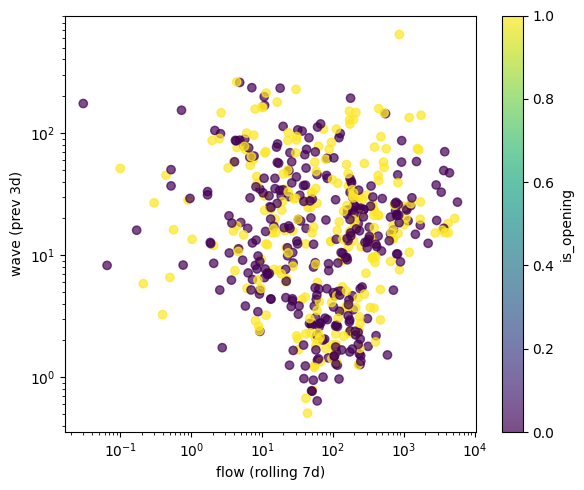

In [41]:
fig, ax = plt.subplots(figsize=(6, 5))

sc = ax.scatter(
    subset["flow_rolling_7d"],
    subset["wave_prev_3d"],
    c=subset["is_opening"],
    alpha=0.7,
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("flow (rolling 7d)")
ax.set_ylabel("wave (prev 3d)")

plt.colorbar(sc, label="is_opening")
plt.tight_layout()
plt.show()

In [42]:
monthly_stats = daily.groupby(["region", "month"], as_index=False).agg(
    # response
    p_open_mean=("p_open", "mean"),
    p_open_std=("p_open", "std"),
    # flow
    streamflow_mean_mean=("streamflow_mean", "mean"),
    streamflow_mean_std=("streamflow_mean", "std"),
    streamflow_mean_max=("streamflow_mean", "max"),
    # wave Hs
    wave_hs_max_mean=("wave_hs_max", "mean"),
    wave_hs_max_std=("wave_hs_max", "std"),
    wave_hs_max_max=("wave_hs_max", "max"),
    # wave period
    wave_tp_max_mean=("wave_tp_max", "mean"),
    wave_tp_max_std=("wave_tp_max", "std"),
    wave_tp_max_max=("wave_tp_max", "max"),
    # wave cross
    wave_energy_cross_max_mean=("wave_energy_cross_max", "mean"),
    wave_energy_cross_max_std=("wave_energy_cross_max", "std"),
    wave_energy_cross_max_max=("wave_energy_cross_max", "max"),
    # wave along
    wave_energy_along_max_mean=("wave_energy_along_max", "mean"),
    wave_energy_along_max_std=("wave_energy_along_max", "std"),
    wave_energy_along_max_max=("wave_energy_along_max", "max"),
    # tide
    tide_range_mean=("tide_range", "mean"),
    tide_range_std=("tide_range", "std"),
    tide_range_max=("tide_range", "max"),
    n_days=("date", "size"),
)

monthly_stats["time"] = pd.to_datetime(
    dict(
        year=2021,
        month=monthly_stats["month"],
        day=1,
    )
)

monthly_stats.head()

,region,month,p_open_mean,p_open_std,streamflow_mean_mean,streamflow_mean_std,streamflow_mean_max,wave_hs_max_mean,wave_hs_max_std,wave_hs_max_max,...,wave_energy_cross_max_std,wave_energy_cross_max_max,wave_energy_along_max_mean,wave_energy_along_max_std,wave_energy_along_max_max,tide_range_mean,tide_range_std,tide_range_max,n_days,time
0,11,1,0.992633,0.038228,19.268512,72.374407,707.261458,1.306517,0.594111,3.945155,...,28.293070,231.990663,3.571478,4.200055,35.993911,1.624624,0.498964,2.555559,248,2021-01-01
1,11,2,0.971094,0.121980,29.294770,82.809895,703.251042,1.158286,0.557380,4.160058,...,21.028875,171.820788,2.901848,2.841815,21.483037,1.618549,0.416331,2.491698,226,2021-02-01
2,11,3,0.941872,0.224673,27.136553,56.806196,550.935417,1.196680,0.480303,3.137512,...,15.228128,89.292869,3.183913,2.141788,12.114033,1.620084,0.293983,2.325963,248,2021-03-01
3,11,4,0.619360,0.454460,19.051424,88.663674,1087.625000,1.067150,0.377712,2.679253,...,10.908745,69.322057,3.167726,1.909325,8.966207,1.610436,0.264079,2.410314,240,2021-04-01
4,11,5,0.727028,0.397775,4.055304,3.552591,33.707292,1.035130,0.321083,2.264820,...,8.799429,61.774373,3.879358,2.389664,14.561932,1.574517,0.354566,2.440119,248,2021-05-01


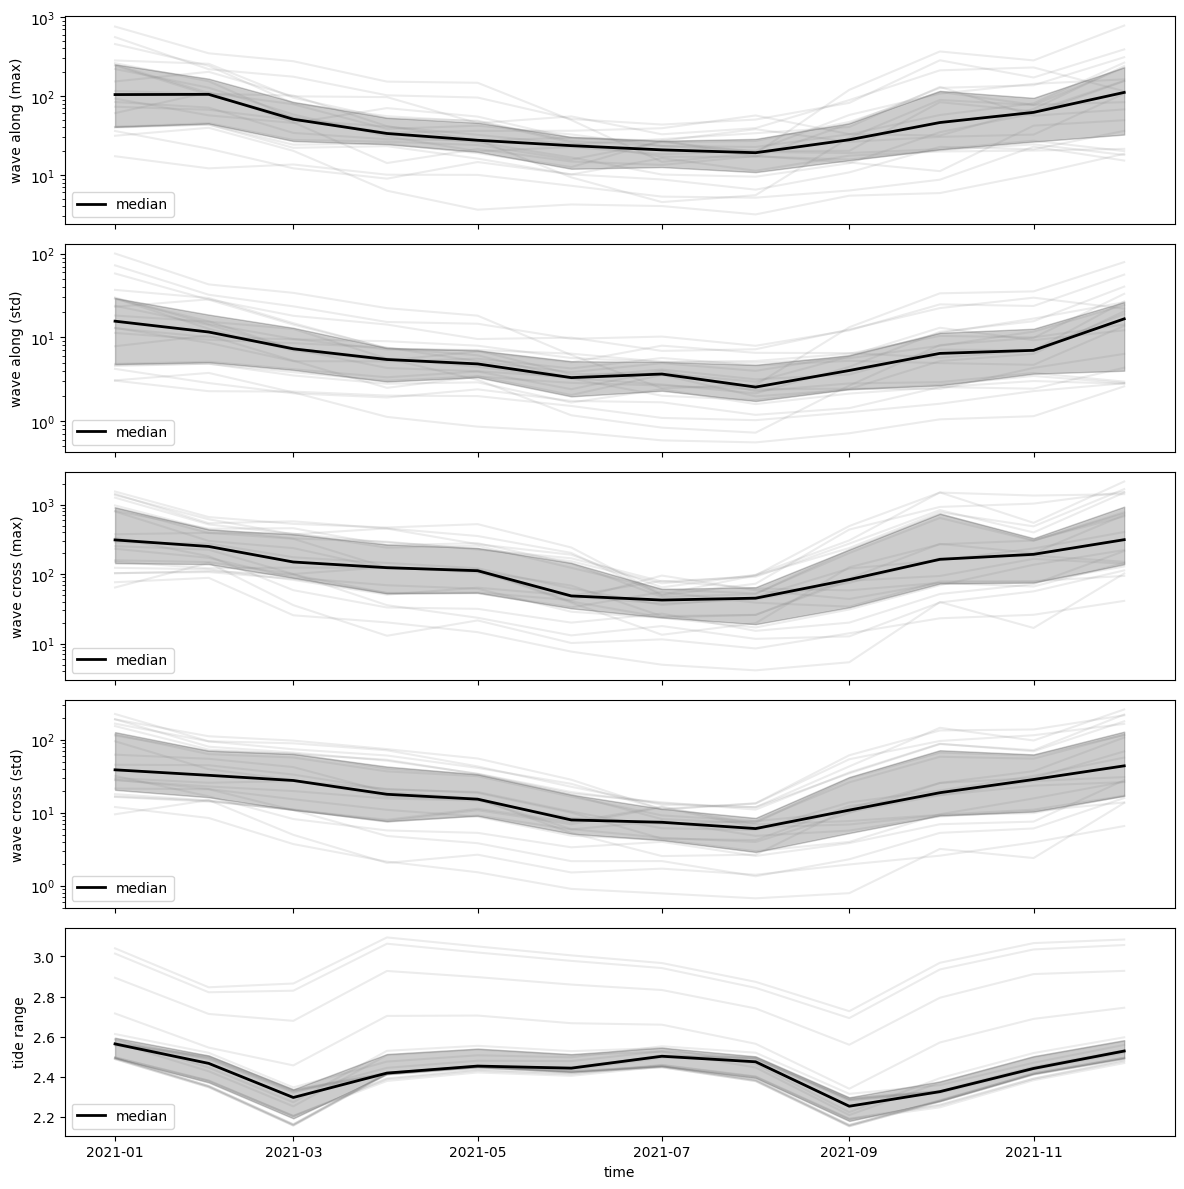

In [43]:
def plot_multi_region_with_iqr(ax, df, x_col, y_col, label, log=False):
    # all regions (faint)
    for _, sub in df.groupby("region"):
        ax.plot(sub[x_col], sub[y_col], color="gray", alpha=0.15)

    # median + IQR
    grouped = df.groupby(x_col)[y_col]
    med = grouped.median()
    q25 = grouped.quantile(0.25)
    q75 = grouped.quantile(0.75)

    ax.plot(med.index, med.values, color="black", lw=2, label="median")
    ax.fill_between(med.index, q25, q75, color="black", alpha=0.2)

    if log:
        ax.set_yscale("log")

    ax.set_ylabel(label)
    ax.legend()


fig, axes = plt.subplots(5, 1, figsize=(12, 12), sharex=True)

plot_multi_region_with_iqr(
    axes[0],
    monthly_stats,
    "time",
    "wave_energy_along_max_max",
    "wave along (max)",
    log=True,
)

plot_multi_region_with_iqr(
    axes[1],
    monthly_stats,
    "time",
    "wave_energy_along_max_std",
    "wave along (std)",
    log=True,
)

plot_multi_region_with_iqr(
    axes[2],
    monthly_stats,
    "time",
    "wave_energy_cross_max_max",
    "wave cross (max)",
    log=True,
)

plot_multi_region_with_iqr(
    axes[3],
    monthly_stats,
    "time",
    "wave_energy_cross_max_std",
    "wave cross (std)",
    log=True,
)

plot_multi_region_with_iqr(
    axes[4],
    monthly_stats,
    "time",
    "tide_range_max",
    "tide range",
)

axes[-1].set_xlabel("time")

plt.tight_layout()
plt.show()

In [44]:
site_mean = daily.groupby("region", as_index=False).agg(
    mean_p_open=("p_open", "mean"),
    # flow
    mean_flow_max=("streamflow_max", "mean"),
    # max_flow_max=("streamflow_max", "max"),
    # wave
    mean_wave_cross=("wave_energy_cross_p90", "mean"),
    # max_wave_cross=("wave_energy_cross_p90", "max"),
    mean_wave_along=("wave_energy_along_p90", "mean"),
    # tide
    mean_tide_range=("tide_range", "mean"),
    max_tide_range=("tide_range", "max"),
    n_days=("date", "size"),
)
site_mean["region"] = site_mean["region"].astype(int)
site_mean = site_mean.set_index("region")
site_mean = site_mean.merge(
    gdf.geometry.centroid.y.rename("lat"), left_index=True, right_index=True, how="left"
)
site_mean

/var/folders/pr/1dt1qk511zdgzhfy1xskpqm00000gn/T/ipykernel_84770/2991774144.py:25: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  site_mean = site_mean.merge(gdf.geometry.centroid.y.rename("lat"), left_index=True, right_index=True, how='left')


,mean_p_open,mean_flow_max,mean_wave_cross,mean_wave_along,mean_tide_range,max_tide_range,n_days,lat
region,,,,,,,,
11,0.937459,27.853433,13.628382,2.554474,1.597142,2.555559,2908,32.934159
14,0.763199,32.482116,14.255892,3.980895,1.601914,2.562440,2908,33.202465
15,0.880973,110.246390,13.475715,3.816471,1.603706,2.565214,2908,33.231817
16,0.053378,1.699936,12.812346,3.367458,1.605225,2.567506,2908,33.290358
21,0.838475,123.246913,9.660167,6.232050,1.645401,2.613231,2908,34.275038
22,0.356095,14.054335,6.925890,1.379538,1.629865,2.584101,2908,34.390513
31,0.375723,164.181201,81.184198,8.053969,1.588873,2.491839,2908,34.692668
32,0.156352,6.142172,61.556133,8.558247,1.594513,2.497096,2908,34.799136
33,0.103116,122.892437,67.127846,6.887380,1.598091,2.496764,2908,34.968980


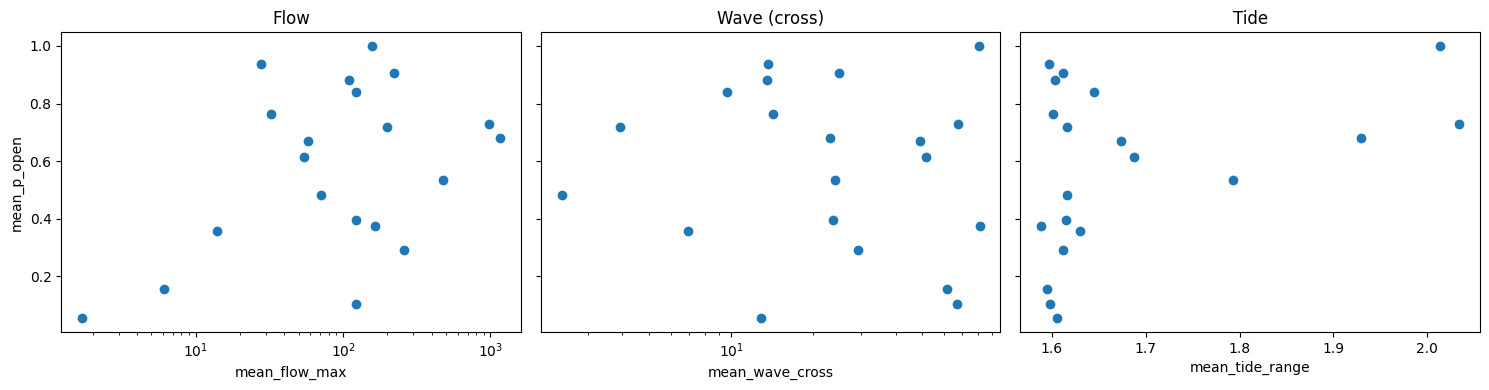

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

# Flow
axes[0].scatter(site_mean["mean_flow_max"], site_mean["mean_p_open"])
axes[0].set_xscale("log")
axes[0].set_xlabel("mean_flow_max")
axes[0].set_ylabel("mean_p_open")
axes[0].set_title("Flow")

# Wave
axes[1].scatter(site_mean["mean_wave_cross"], site_mean["mean_p_open"])
axes[1].set_xscale("log")
axes[1].set_xlabel("mean_wave_cross")
axes[1].set_title("Wave (cross)")

# Tide
axes[2].scatter(site_mean["mean_tide_range"], site_mean["mean_p_open"])
axes[2].set_xlabel("mean_tide_range")
axes[2].set_title("Tide")

plt.tight_layout()
plt.show()

array([[<Axes: xlabel='mean_p_open', ylabel='mean_p_open'>,
        <Axes: xlabel='mean_flow_max', ylabel='mean_p_open'>,
        <Axes: xlabel='mean_wave_cross', ylabel='mean_p_open'>,
        <Axes: xlabel='mean_wave_along', ylabel='mean_p_open'>,
        <Axes: xlabel='mean_tide_range', ylabel='mean_p_open'>,
        <Axes: xlabel='lat', ylabel='mean_p_open'>],
       [<Axes: xlabel='mean_p_open', ylabel='mean_flow_max'>,
        <Axes: xlabel='mean_flow_max', ylabel='mean_flow_max'>,
        <Axes: xlabel='mean_wave_cross', ylabel='mean_flow_max'>,
        <Axes: xlabel='mean_wave_along', ylabel='mean_flow_max'>,
        <Axes: xlabel='mean_tide_range', ylabel='mean_flow_max'>,
        <Axes: xlabel='lat', ylabel='mean_flow_max'>],
       [<Axes: xlabel='mean_p_open', ylabel='mean_wave_cross'>,
        <Axes: xlabel='mean_flow_max', ylabel='mean_wave_cross'>,
        <Axes: xlabel='mean_wave_cross', ylabel='mean_wave_cross'>,
        <Axes: xlabel='mean_wave_along', ylabel='mean_wa

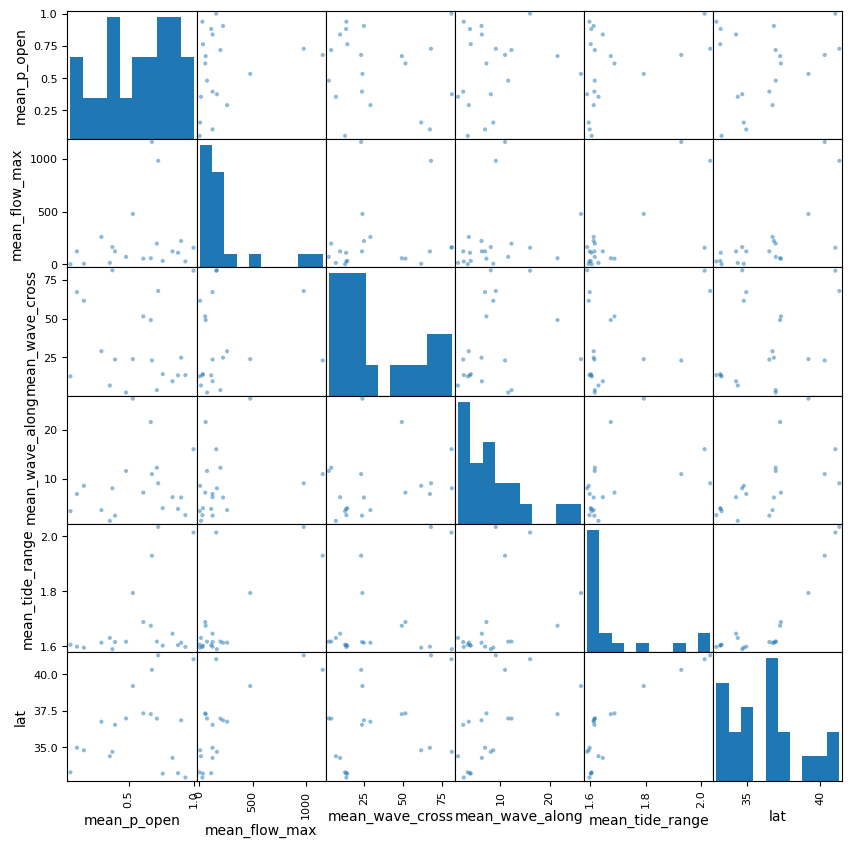

In [46]:
cols = [
    "mean_p_open",
    "mean_flow_max",
    # "max_flow_max",
    "mean_wave_cross",
    # "max_wave_cross",
    "mean_wave_along",
    "mean_tide_range",
    "lat",
    # "max_tide_range",
]

pd.plotting.scatter_matrix(
    site_mean[cols],
    figsize=(10, 10),
    diagonal="hist",
)

In [47]:
site_mean[cols].corr(method="spearman")

,mean_p_open,mean_flow_max,mean_wave_cross,mean_wave_along,mean_tide_range,lat
mean_p_open,1.000000,0.248120,-0.073684,0.157895,0.290226,0.087218
mean_flow_max,0.248120,1.000000,0.275188,0.413534,0.461654,0.627068
mean_wave_cross,-0.073684,0.275188,1.000000,0.294737,0.015038,0.393985
mean_wave_along,0.157895,0.413534,0.294737,1.000000,0.484211,0.727820
mean_tide_range,0.290226,0.461654,0.015038,0.484211,1.000000,0.783459
lat,0.087218,0.627068,0.393985,0.727820,0.783459,1.000000


In [48]:
site_mean.columns

Index(['mean_p_open', 'mean_flow_max', 'mean_wave_cross', 'mean_wave_along',
       'mean_tide_range', 'max_tide_range', 'n_days', 'lat'],
      dtype='str')

Text(0, 0.5, 'wave along sensitivity')

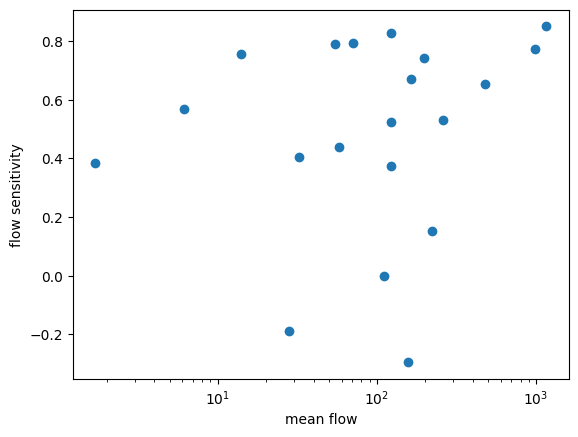

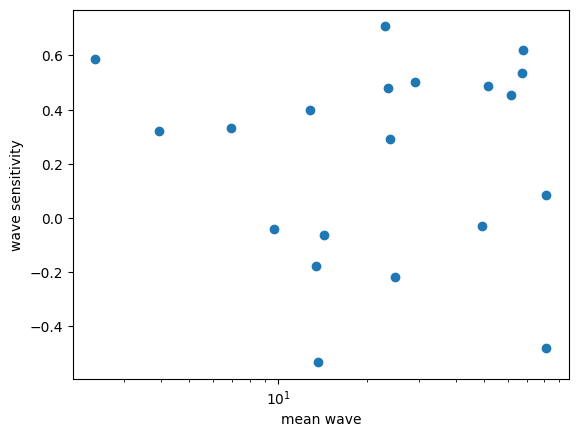

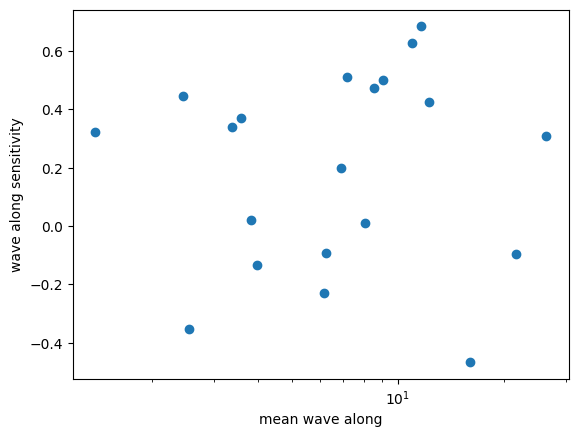

In [49]:
site_sensitivity = []

for region, sub in monthly_ok.groupby("region"):
    sub = sub.dropna(
        subset=["mean_p_open", "streamflow_max", "wave_energy_cross_p90", "wave_energy_along_p90"]
    )

    if len(sub) < 6:
        continue

    flow_r = sub["mean_p_open"].corr(sub["streamflow_max"], method="spearman")
    wave_r = sub["mean_p_open"].corr(sub["wave_energy_cross_p90"], method="spearman")
    wavea_r = sub["mean_p_open"].corr(sub["wave_energy_along_p90"], method="spearman")

    site_sensitivity.append(
        {
            "region": region,
            "rho_flow": flow_r,
            "rho_wave": wave_r,
            "rho_wave_along": wavea_r,
        }
    )

site_sens = pd.DataFrame(site_sensitivity)

plt.figure()
plt.scatter(site_mean["mean_flow_max"], site_sens["rho_flow"])
plt.xscale("log")
plt.xlabel("mean flow")
plt.ylabel("flow sensitivity")

plt.figure()
plt.scatter(site_mean["mean_wave_cross"], site_sens["rho_wave"])
plt.xscale("log")
plt.xlabel("mean wave")
plt.ylabel("wave sensitivity")

plt.figure()
plt.scatter(site_mean["mean_wave_along"], site_sens["rho_wave_along"])
plt.xscale("log")
plt.xlabel("mean wave along")
plt.ylabel("wave along sensitivity")

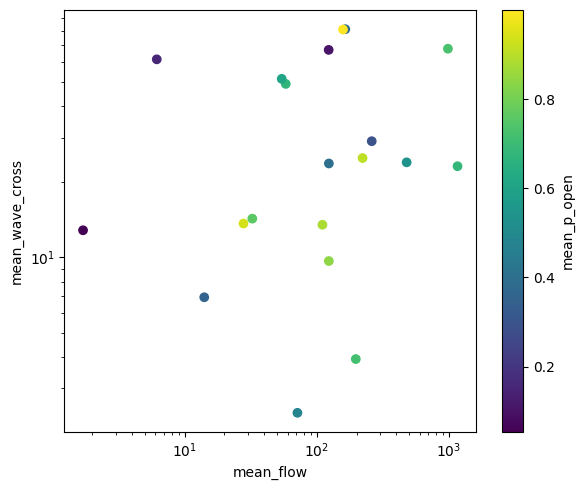

In [50]:
fig, ax = plt.subplots(figsize=(6, 5))

sc = ax.scatter(
    site_mean["mean_flow_max"],
    site_mean["mean_wave_cross"],
    c=site_mean["mean_p_open"],
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("mean_flow")
ax.set_ylabel("mean_wave_cross")

plt.colorbar(sc, label="mean_p_open")
plt.tight_layout()
plt.show()

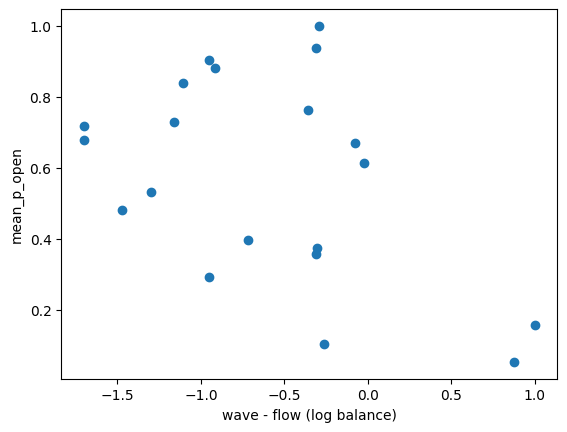

In [51]:
site_mean["wave_flow_balance"] = np.log10(site_mean["mean_wave_cross"] + 1e-6) - np.log10(
    site_mean["mean_flow_max"] + 1e-3
)
plt.scatter(
    site_mean["wave_flow_balance"],
    site_mean["mean_p_open"],
)

plt.xlabel("wave - flow (log balance)")
plt.ylabel("mean_p_open")
plt.show()

Text(0, 0.5, 'p_open')

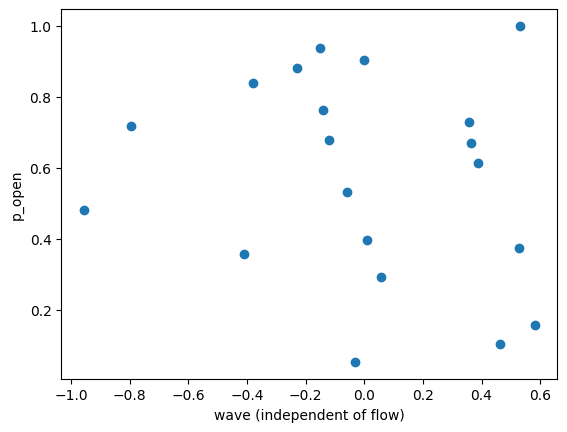

In [52]:
import statsmodels.api as sm

# regress wave on flow
X = sm.add_constant(np.log10(site_mean["mean_flow_max"] + 1e-6))
wave_resid = sm.OLS(np.log10(site_mean["mean_wave_cross"] + 1e-6), X).fit().resid

site_mean["wave_resid"] = wave_resid

plt.scatter(site_mean["wave_resid"], site_mean["mean_p_open"])
plt.xlabel("wave (independent of flow)")
plt.ylabel("p_open")

In [53]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

site_df = daily.copy()
site_df = site_df.dropna(
    subset=[
        "region",
        "date",
        "season",
        "p_open",
        "streamflow_max",
        "wave_energy_cross_p90",
    ]
).copy()

site_df = site_df.sort_values(["region", "date"]).reset_index(drop=True)

# -------------------------
# 1. rank-based normalization
# -------------------------
eps = 1e-4

site_df["flow_rank"] = site_df.groupby("region")["streamflow_max"].rank(method="average", pct=True)
site_df["wave_rank"] = site_df.groupby("region")["wave_energy_cross_p90"].rank(
    method="average", pct=True
)

site_df["flow_rank_clip"] = site_df["flow_rank"].clip(eps, 1 - eps)
site_df["wave_rank_clip"] = site_df["wave_rank"].clip(eps, 1 - eps)

site_df["balance_rank_logratio"] = np.log(site_df["wave_rank_clip"]) - np.log(
    site_df["flow_rank_clip"]
)

# -------------------------
# 2. z-score normalization
# -------------------------
site_df["log_streamflow_max"] = np.log(site_df["streamflow_max"].clip(lower=1e-6))
flow_mu = site_df.groupby("region")["log_streamflow_max"].transform("mean")
flow_sd = site_df.groupby("region")["log_streamflow_max"].transform("std").replace(0, np.nan)

site_df["log_wave_energy_cross_p90"] = np.log(site_df["wave_energy_cross_p90"].clip(lower=1e-6))
wave_mu = site_df.groupby("region")["log_wave_energy_cross_p90"].transform("mean")
wave_sd = site_df.groupby("region")["log_wave_energy_cross_p90"].transform("std").replace(0, np.nan)

site_df["flow_z"] = (site_df["log_streamflow_max"] - flow_mu) / flow_sd
site_df["wave_z"] = (site_df["log_wave_energy_cross_p90"] - wave_mu) / wave_sd
site_df["balance_zdiff"] = site_df["wave_z"] - site_df["flow_z"]

# -------------------------
# 3. unnormalized raw log-ratio
# -------------------------
site_df["balance_raw_logratio"] = (
    site_df["log_streamflow_max"] - site_df["log_wave_energy_cross_p90"]
)

site_df["split"] = np.where(site_df["date"].dt.year % 2 == 0, "even", "odd")

train = site_df[site_df["split"] == "even"]
test = site_df[site_df["split"] == "odd"]

site_df[
    [
        "region",
        "date",
        "season",
        "p_open",
        "log_streamflow_max",
        "log_wave_energy_cross_p90",
        "balance_rank_logratio",
        "balance_zdiff",
        "balance_raw_logratio",
    ]
].head()

,region,date,season,p_open,log_streamflow_max,log_wave_energy_cross_p90,balance_rank_logratio,balance_zdiff,balance_raw_logratio
0,11,2018-01-01,winter,0.999994,0.888920,1.038502,-2.702013,-1.254283,-0.149583
1,11,2018-01-02,winter,0.999994,0.907250,1.154298,-2.274975,-1.113255,-0.247048
2,11,2018-01-03,winter,0.999994,0.978326,1.703791,-0.733836,-0.432494,-0.725465
3,11,2018-01-04,winter,0.999995,0.916291,2.318464,0.295433,0.431618,-1.402173
4,11,2018-01-05,winter,0.999995,0.916291,2.899990,0.639722,1.206589,-1.983699


In [54]:
def estimate_thresholds(
    df: pd.DataFrame,
    group_cols,
    balance_col: str,
    open_thresh: float = 0.7,
    closed_thresh: float = 0.3,
    min_each_class: int = 20,
) -> pd.DataFrame:
    rows = []

    if isinstance(group_cols, str):
        group_cols = [group_cols]

    for keys, sub in df.groupby(group_cols):
        sub = sub.dropna(subset=["p_open", balance_col]).copy()

        open_sub = sub[sub["p_open"] >= open_thresh]
        closed_sub = sub[sub["p_open"] <= closed_thresh]

        if len(open_sub) < min_each_class or len(closed_sub) < min_each_class:
            continue

        open_med = open_sub[balance_col].median()
        closed_med = closed_sub[balance_col].median()
        threshold = 0.5 * (open_med + closed_med)

        row = {
            "n_total": len(sub),
            "n_open": len(open_sub),
            "n_closed": len(closed_sub),
            "open_med": open_med,
            "closed_med": closed_med,
            "threshold": threshold,
            "sep": closed_med - open_med,
            "balance_col": balance_col,
        }

        if not isinstance(keys, tuple):
            keys = (keys,)

        for col, val in zip(group_cols, keys):
            row[col] = val

        rows.append(row)

    out = pd.DataFrame(rows)
    if len(out) == 0:
        return out

    return out.sort_values(group_cols).reset_index(drop=True)


balance_cols = [
    "balance_rank_logratio",
    "balance_zdiff",
    "balance_raw_logratio",
]

# -------------------------
# Per-site thresholds
# -------------------------
site_thresh_all = pd.concat(
    [
        estimate_thresholds(
            train,
            group_cols=["region"],
            balance_col=col,
            open_thresh=0.7,
            closed_thresh=0.3,
            min_each_class=10,
        )
        for col in balance_cols
    ],
    ignore_index=True,
)

site_thresh_all.head()

# -------------------------
# Per-site x season thresholds
# -------------------------
site_season_thresh_all = pd.concat(
    [
        estimate_thresholds(
            train,
            group_cols=["region", "season"],
            balance_col=col,
            open_thresh=0.7,
            closed_thresh=0.3,
            min_each_class=10,
        )
        for col in balance_cols
    ],
    ignore_index=True,
)

site_season_thresh_all.head()

,n_total,n_open,n_closed,open_med,closed_med,threshold,sep,balance_col,region,season
0,368,296,53,-0.183672,0.869440,0.342884,1.053111,balance_rank_logratio,11,spring
1,364,182,182,0.337437,1.104477,0.720957,0.767041,balance_rank_logratio,14,fall
2,368,317,36,-0.206442,1.210973,0.502266,1.417415,balance_rank_logratio,14,spring
3,368,234,134,-0.116209,0.928159,0.405975,1.044368,balance_rank_logratio,14,summer
4,362,326,32,-0.164666,-0.348337,-0.256501,-0.183672,balance_rank_logratio,14,winter


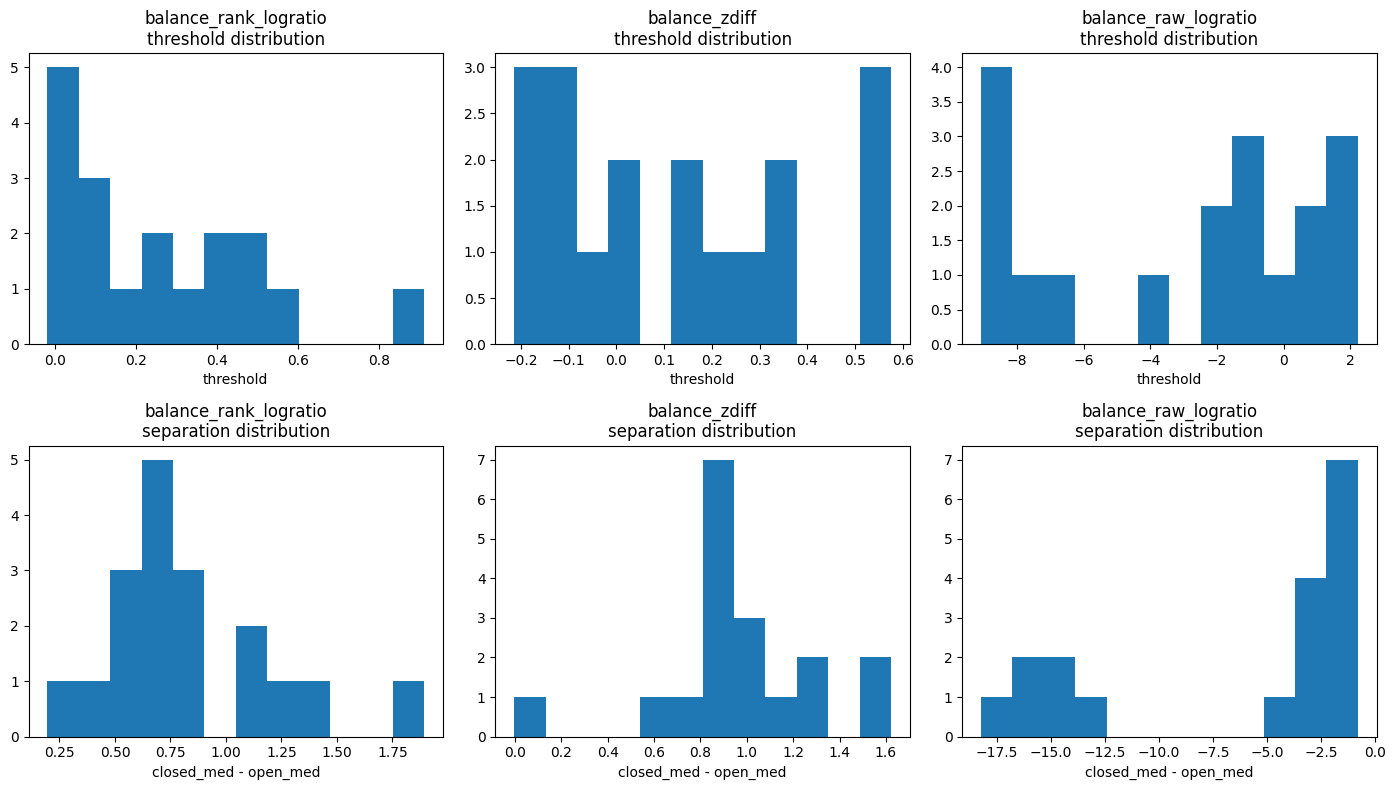

threshold                                     \
balance_col balance_rank_logratio balance_raw_logratio balance_zdiff   
region                                                                 
11                       0.457809            -1.545457      0.575119   
14                       0.408159            -8.601657      0.375503   
15                       0.335125            -8.799277      0.541597   
21                       0.581985            -0.508381      0.362896   
22                      -0.019090            -7.287289     -0.191248   
31                       0.008444            -9.084111     -0.101901   
32                       0.024607            -3.649034     -0.214368   
33                       0.047122            -8.847901     -0.076277   
48                       0.068226            -0.620871      0.037151   
50                      -0.008257            -7.105387     -0.113483   
51                       0.912535            -1.225368      0.556582   
56                       0.431671             2.217874      0.246918   
57                       0.122101             1.964078     -0.011952   
84                       0.063378             0.897091     -0.187202   
92                       0.239042             2.157545      0.131087   
96                       0.453369             1.225793      0.176832   
2138                     0.265140            -1.823310      0.184347   
13057                    0.204803            -2.102118     -0.124149   

                              sep                                     
balance_col balance_rank_logratio balance_raw_logratio balance_zdiff  
region                                                                
11                       0.823262            -0.816302      0.960890  
14                       1.118892           -15.119717      1.621752  
15                       0.655592           -14.360984      0.884635  
21                       1.441214            -2.162449      1.162202  
22                       0.685648           -13.820244      1.229340  
31                       0.846058           -16.746165      1.507135  
32                       0.348600            -1.224058      0.863722  
33                       0.195861           -16.694469      0.725448  
48                       0.630630            -4.112972      0.829237  
50                       0.482437           -18.232677      0.978033  
51                       1.892953            -3.240573      1.250086  
56                       1.240756            -1.418482      0.958959  
57                       0.716887            -1.510036      0.894056  
84                       0.586427            -2.758551      0.654426  
92                       0.692108            -2.394501      0.819124  
96                       1.117031            -2.637359      0.868254  
2138                     0.778038            -1.401778      0.826842  
13057                    0.579852            -2.105696     -0.003739

Primary method: balance_rank_logratio


,n_total,n_open,n_closed,open_med,closed_med,threshold,sep,balance_col,region
0,1462,1389,53,0.046178,0.869440,0.457809,0.823262,balance_rank_logratio,11
1,1462,1059,384,-0.151287,0.967605,0.408159,1.118892,balance_rank_logratio,14
2,1432,1274,127,0.007328,0.662921,0.335125,0.655592,balance_rank_logratio,15
3,1462,1169,249,-0.138622,1.302592,0.581985,1.441214,balance_rank_logratio,21
4,1462,437,930,-0.361914,0.323734,-0.019090,0.685648,balance_rank_logratio,22


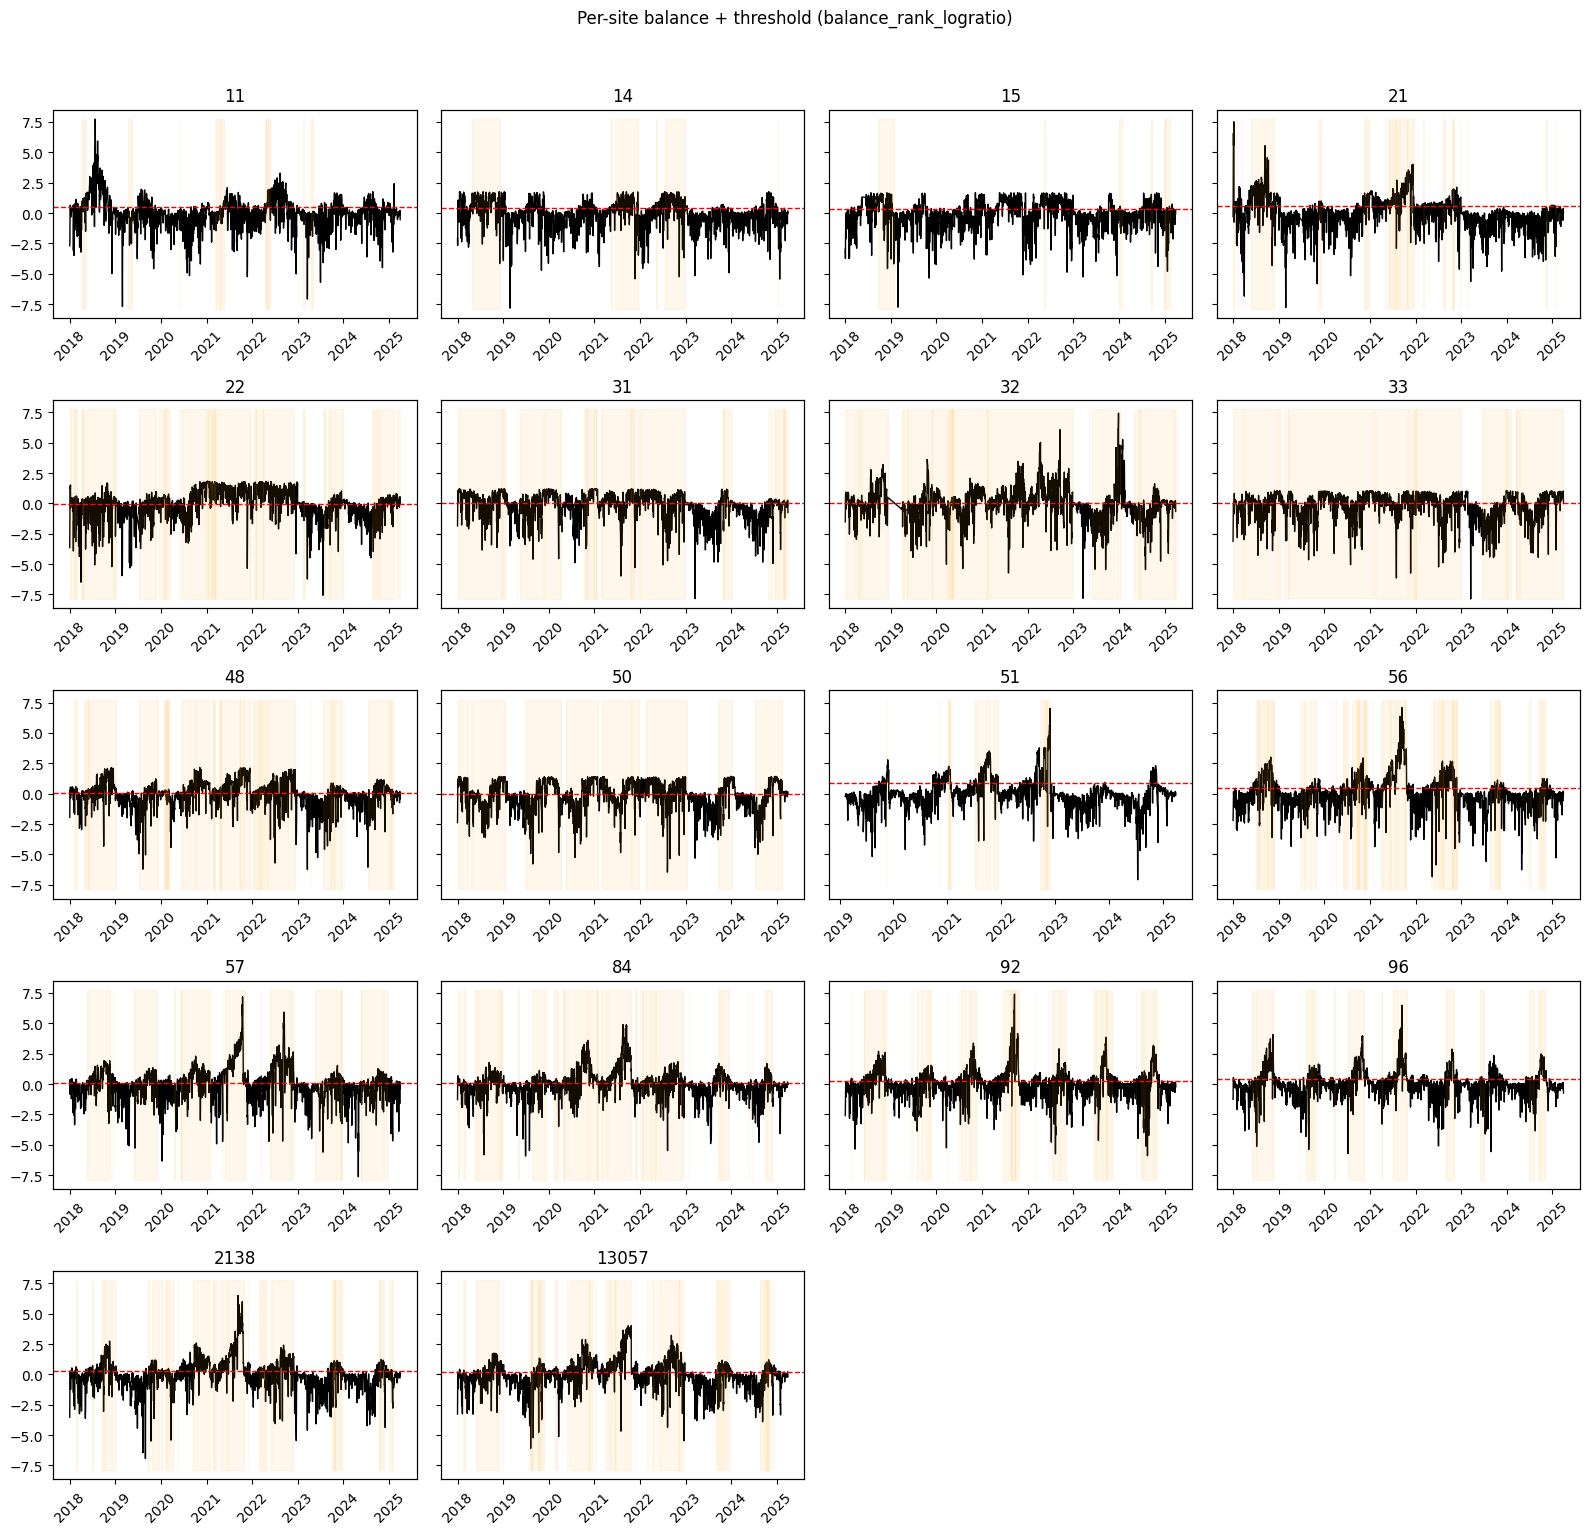

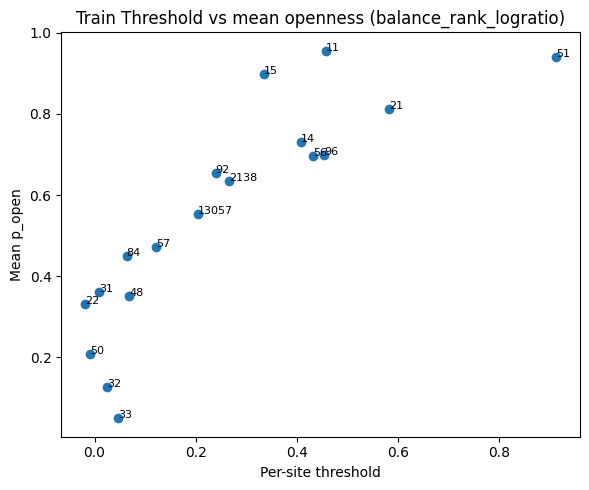

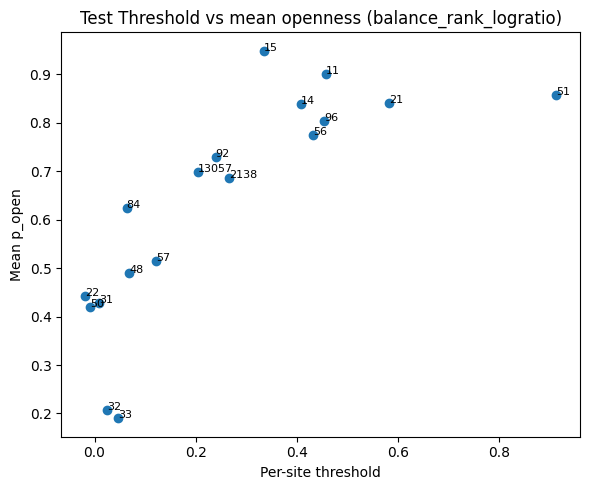

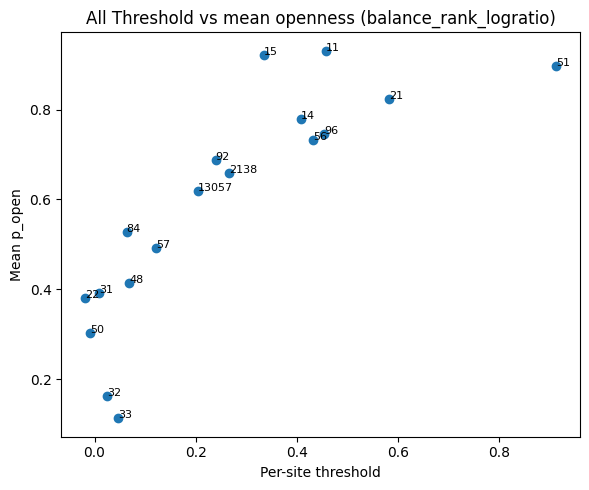

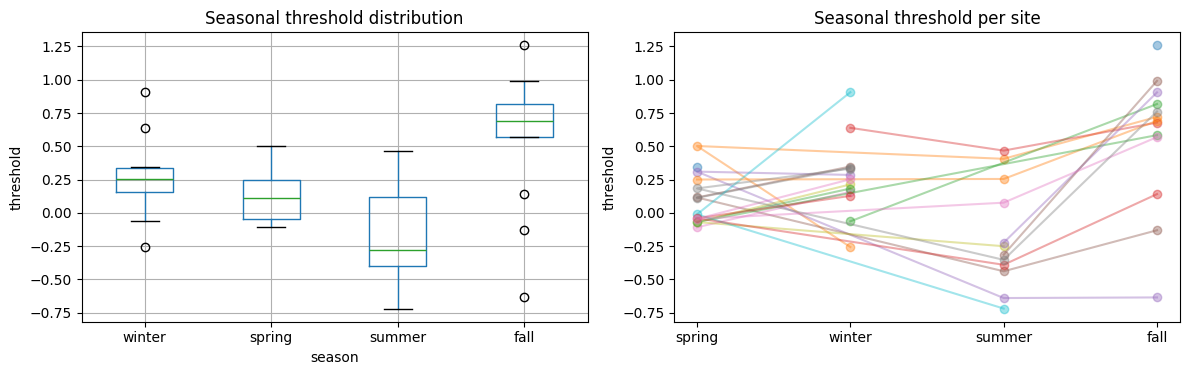

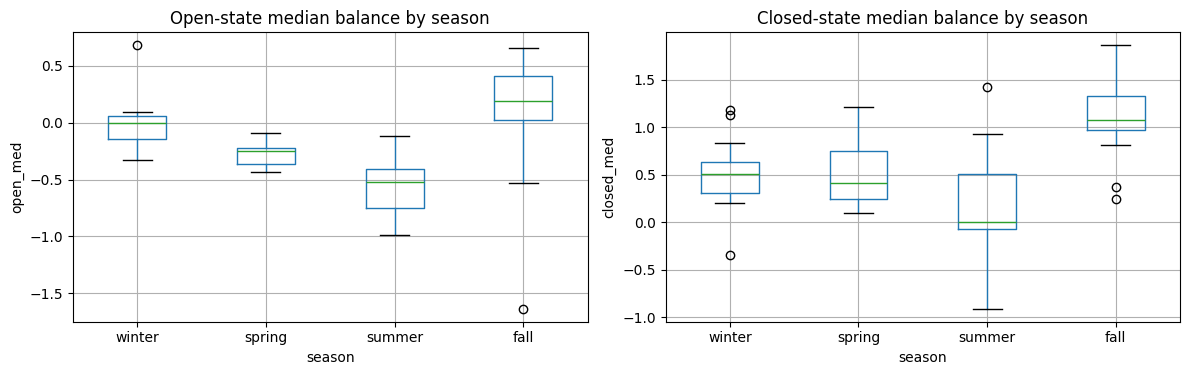

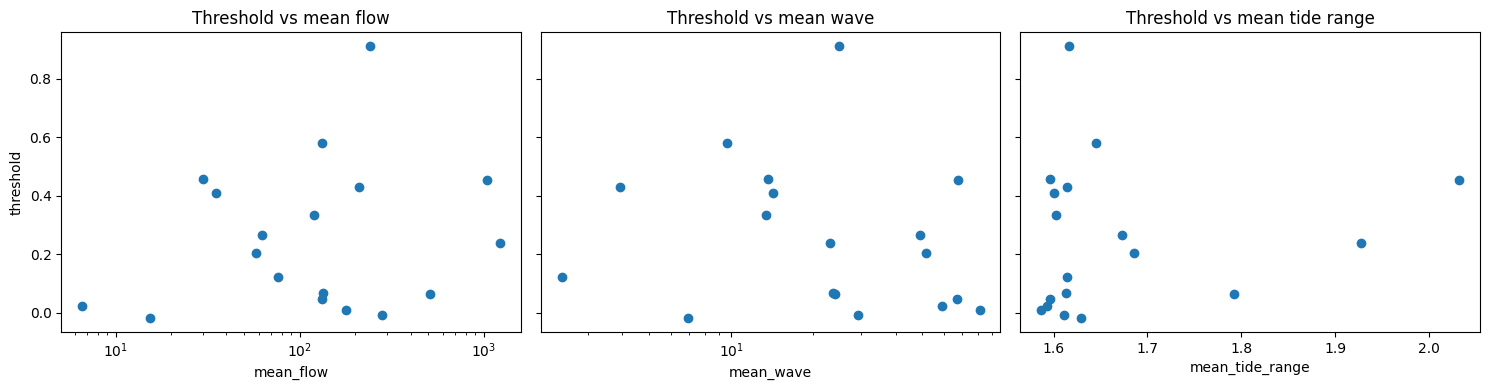

Per-site threshold relationships


,threshold,mean_p_open,mean_flow,mean_wave,mean_tide_range
threshold,1.000000,0.909185,0.139319,-0.263158,0.267286
mean_p_open,0.909185,1.000000,0.087719,-0.378741,0.226006
mean_flow,0.139319,0.087719,1.000000,0.184727,0.461300
mean_wave,-0.263158,-0.378741,0.184727,1.000000,-0.085655
mean_tide_range,0.267286,0.226006,0.461300,-0.085655,1.000000


Seasonal threshold relationships


,threshold,open_med,closed_med,sep
threshold,1.000000,0.857195,0.945973,0.393032
open_med,0.857195,1.000000,0.679548,-0.049593
closed_med,0.945973,0.679548,1.000000,0.641176
sep,0.393032,-0.049593,0.641176,1.000000


In [55]:
# -------------------------
# 1. threshold distributions by method
# -------------------------
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for i, col in enumerate(balance_cols):
    sub = site_thresh_all[site_thresh_all["balance_col"] == col]

    axes[0, i].hist(sub["threshold"], bins=12)
    axes[0, i].set_title(f"{col}\nthreshold distribution")
    axes[0, i].set_xlabel("threshold")

    axes[1, i].hist(sub["sep"], bins=12)
    axes[1, i].set_title(f"{col}\nseparation distribution")
    axes[1, i].set_xlabel("closed_med - open_med")

plt.tight_layout()
plt.show()


# -------------------------
# 2. compare site thresholds across methods
# -------------------------
site_thresh_wide = site_thresh_all[["region", "balance_col", "threshold", "sep"]].pivot(
    index="region", columns="balance_col", values=["threshold", "sep"]
)

display(site_thresh_wide)


# -------------------------
# 3. pick one primary method for detailed plots
# -------------------------
primary_balance = "balance_rank_logratio"

site_thresh = site_thresh_all[site_thresh_all["balance_col"] == primary_balance].copy()
site_season_thresh = site_season_thresh_all[
    site_season_thresh_all["balance_col"] == primary_balance
].copy()

print("Primary method:", primary_balance)
display(site_thresh.head())


# -------------------------
# 4. per-site time series of balance + threshold
# -------------------------
plot_df = site_df.merge(
    site_thresh[["region", "threshold"]],
    on="region",
    how="inner",
).copy()

regions = sorted(plot_df["region"].unique())
n = len(regions)
ncols = 4
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3 * nrows), sharex=False, sharey=True)
axes = np.array(axes).reshape(-1)

for ax, region in zip(axes, regions):
    sub = plot_df[plot_df["region"] == region].sort_values("date")

    ax.plot(sub["date"], sub[primary_balance], color="black", linewidth=1)
    ax.axhline(sub["threshold"].iloc[0], color="red", linestyle="--", linewidth=1)

    ax2 = ax.twinx()
    mask = sub["p_open"] < 0.5
    ax2.fill_between(
        sub["date"],
        0,
        1,
        where=mask,
        color="orange",
        alpha=0.08,
    )
    # ax2.fill_between(d.index, d["q25"], d["q75"], alpha=0.3, label="IQR")
    # ax2.plot(sub["date"], sub["p_open"], color="tab:blue", alpha=0.25, linewidth=1)
    ax2.set_ylim(-0.05, 1.05)
    ax2.set_yticks([])

    ax.set_title(str(region))
    ax.tick_params(axis="x", rotation=45)

for ax in axes[n:]:
    ax.set_visible(False)

fig.suptitle(f"Per-site balance + threshold ({primary_balance})", y=1.02)
plt.tight_layout()
plt.show()


# -------------------------
# 5. threshold vs mean openness
# -------------------------
site_mean = train.groupby("region", as_index=False).agg(
    mean_p_open=("p_open", "mean"),
    mean_flow=("streamflow_max", "mean"),
    mean_wave=("wave_energy_cross_p90", "mean"),
    mean_tide_range=("tide_range", "mean"),
)

site_summary = site_thresh.merge(site_mean, on="region", how="left")

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(site_summary["threshold"], site_summary["mean_p_open"])

for _, row in site_summary.iterrows():
    ax.text(row["threshold"], row["mean_p_open"], str(row["region"]), fontsize=8)

ax.set_xlabel("Per-site threshold")
ax.set_ylabel("Mean p_open")
ax.set_title(f"Train Threshold vs mean openness ({primary_balance})")
plt.tight_layout()
plt.show()

site_mean = test.groupby("region", as_index=False).agg(
    mean_p_open=("p_open", "mean"),
    mean_flow=("streamflow_max", "mean"),
    mean_wave=("wave_energy_cross_p90", "mean"),
    mean_tide_range=("tide_range", "mean"),
)

site_summary = site_thresh.merge(site_mean, on="region", how="left")

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(site_summary["threshold"], site_summary["mean_p_open"])

for _, row in site_summary.iterrows():
    ax.text(row["threshold"], row["mean_p_open"], str(row["region"]), fontsize=8)

ax.set_xlabel("Per-site threshold")
ax.set_ylabel("Mean p_open")
ax.set_title(f"Test Threshold vs mean openness ({primary_balance})")
plt.tight_layout()
plt.show()

site_mean = site_df.groupby("region", as_index=False).agg(
    mean_p_open=("p_open", "mean"),
    mean_flow=("streamflow_max", "mean"),
    mean_wave=("wave_energy_cross_p90", "mean"),
    mean_tide_range=("tide_range", "mean"),
)

site_summary = site_thresh.merge(site_mean, on="region", how="left")

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(site_summary["threshold"], site_summary["mean_p_open"])

for _, row in site_summary.iterrows():
    ax.text(row["threshold"], row["mean_p_open"], str(row["region"]), fontsize=8)

ax.set_xlabel("Per-site threshold")
ax.set_ylabel("Mean p_open")
ax.set_title(f"All Threshold vs mean openness ({primary_balance})")
plt.tight_layout()
plt.show()


# -------------------------
# 6. seasonal thresholds
# -------------------------
season_order = ["winter", "spring", "summer", "fall"]
site_season_thresh["season"] = pd.Categorical(
    site_season_thresh["season"],
    categories=season_order,
    ordered=True,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# boxplot-style using pandas
site_season_thresh.boxplot(column="threshold", by="season", ax=axes[0])
axes[0].set_title("Seasonal threshold distribution")
axes[0].set_ylabel("threshold")

# line per site
for region, sub in site_season_thresh.groupby("region"):
    sub = sub.sort_values("season")
    axes[1].plot(sub["season"], sub["threshold"], marker="o", alpha=0.4)

axes[1].set_title("Seasonal threshold per site")
axes[1].set_ylabel("threshold")

plt.suptitle("")
plt.tight_layout()
plt.show()


# -------------------------
# 7. open_med / closed_med by season
# -------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

site_season_thresh.boxplot(column="open_med", by="season", ax=axes[0])
axes[0].set_title("Open-state median balance by season")
axes[0].set_ylabel("open_med")

site_season_thresh.boxplot(column="closed_med", by="season", ax=axes[1])
axes[1].set_title("Closed-state median balance by season")
axes[1].set_ylabel("closed_med")

plt.suptitle("")
plt.tight_layout()
plt.show()


# -------------------------
# 8. threshold controls
# -------------------------
site_summary = site_summary.sort_values("region").reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

axes[0].scatter(site_summary["mean_flow"], site_summary["threshold"])
axes[0].set_xscale("log")
axes[0].set_xlabel("mean_flow")
axes[0].set_ylabel("threshold")
axes[0].set_title("Threshold vs mean flow")

axes[1].scatter(site_summary["mean_wave"], site_summary["threshold"])
axes[1].set_xscale("log")
axes[1].set_xlabel("mean_wave")
axes[1].set_title("Threshold vs mean wave")

axes[2].scatter(site_summary["mean_tide_range"], site_summary["threshold"])
axes[2].set_xlabel("mean_tide_range")
axes[2].set_title("Threshold vs mean tide range")

plt.tight_layout()
plt.show()


# -------------------------
# 9. correlation tables
# -------------------------
print("Per-site threshold relationships")
display(
    site_summary[["threshold", "mean_p_open", "mean_flow", "mean_wave", "mean_tide_range"]].corr(
        method="spearman"
    )
)

print("Seasonal threshold relationships")
display(site_season_thresh[["threshold", "open_med", "closed_med", "sep"]].corr(method="spearman"))

In [56]:
def evaluate_threshold_balanced(
    df,
    balance_col,
    threshold_df,
    threshold_cols,
):
    eval_df = df.copy()

    # merge thresholds
    eval_df = eval_df.merge(
        threshold_df[threshold_cols + ["threshold"]],
        on=threshold_cols,
        how="inner",
    )

    # predictions
    eval_df["pred_closed"] = eval_df[balance_col] >= eval_df["threshold"]

    # observations
    eval_df["obs_closed"] = eval_df["p_open"] <= 0.3
    eval_df["obs_open"] = eval_df["p_open"] >= 0.7

    eval_df = eval_df[eval_df["obs_closed"] | eval_df["obs_open"]].copy()

    def compute_balanced(g):
        tp = ((g["pred_closed"] == 1) & (g["obs_closed"])).sum()
        fn = ((g["pred_closed"] == 0) & (g["obs_closed"])).sum()
        tn = ((g["pred_closed"] == 0) & (g["obs_open"])).sum()
        fp = ((g["pred_closed"] == 1) & (g["obs_open"])).sum()

        tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        tnr = tn / (tn + fp) if (tn + fp) > 0 else np.nan

        return pd.Series(
            {
                "n": len(g),
                "tpr": tpr,
                "tnr": tnr,
                "balanced_acc": np.nanmean([tpr, tnr]),
            }
        )

    # per-site
    site_stats = eval_df.groupby("region").apply(compute_balanced).reset_index()

    # overall
    overall = compute_balanced(eval_df)

    return site_stats, overall


results = []

for balance_col in [
    "balance_rank_logratio",
    "balance_zdiff",
    "balance_raw_logratio",
]:
    # global threshold
    thresh_global = site_thresh_all[site_thresh_all["balance_col"] == balance_col][
        ["region", "threshold"]
    ]

    site_stats, overall = evaluate_threshold_balanced(
        test,
        balance_col,
        thresh_global,
        ["region"],
    )

    results.append(
        {
            "balance": balance_col,
            "threshold_type": "global",
            "balanced_acc": overall["balanced_acc"],
            "tpr": overall["tpr"],
            "tnr": overall["tnr"],
            "mean_site_bal_acc": site_stats["balanced_acc"].mean(),
        }
    )

    # seasonal threshold
    thresh_season = site_season_thresh_all[site_season_thresh_all["balance_col"] == balance_col][
        ["region", "season", "threshold"]
    ]

    site_stats, overall = evaluate_threshold_balanced(
        test,
        balance_col,
        thresh_season,
        ["region", "season"],
    )

    results.append(
        {
            "balance": balance_col,
            "threshold_type": "seasonal",
            "balanced_acc": overall["balanced_acc"],
            "tpr": overall["tpr"],
            "tnr": overall["tnr"],
            "mean_site_bal_acc": site_stats["balanced_acc"].mean(),
        }
    )

results_df = pd.DataFrame(results)
results_df

,balance,threshold_type,balanced_acc,tpr,tnr,mean_site_bal_acc
0,balance_rank_logratio,global,0.722906,0.608182,0.837630,0.715080
1,balance_rank_logratio,seasonal,0.728895,0.643272,0.814519,0.715513
2,balance_zdiff,global,0.680536,0.642916,0.718155,0.673961
3,balance_zdiff,seasonal,0.705094,0.673779,0.736410,0.687606
4,balance_raw_logratio,global,0.229101,0.299286,0.158917,0.226991
5,balance_raw_logratio,seasonal,0.220212,0.291409,0.149015,0.238642


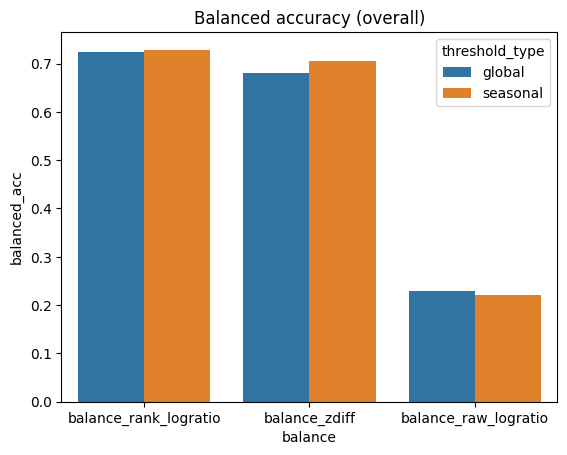

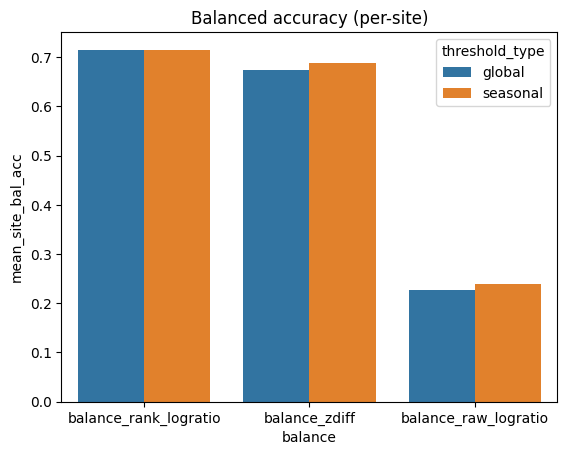

In [57]:
sns.barplot(
    data=results_df,
    x="balance",
    y="balanced_acc",
    hue="threshold_type",
)
plt.title("Balanced accuracy (overall)")
plt.show()

sns.barplot(
    data=results_df,
    x="balance",
    y="mean_site_bal_acc",
    hue="threshold_type",
)
plt.title("Balanced accuracy (per-site)")
plt.show()

In [58]:
results_df[
    [
        "balance",
        "threshold_type",
        "balanced_acc",
        "tpr",
        "tnr",
    ]
]

,balance,threshold_type,balanced_acc,tpr,tnr
0,balance_rank_logratio,global,0.722906,0.608182,0.837630
1,balance_rank_logratio,seasonal,0.728895,0.643272,0.814519
2,balance_zdiff,global,0.680536,0.642916,0.718155
3,balance_zdiff,seasonal,0.705094,0.673779,0.736410
4,balance_raw_logratio,global,0.229101,0.299286,0.158917
5,balance_raw_logratio,seasonal,0.220212,0.291409,0.149015


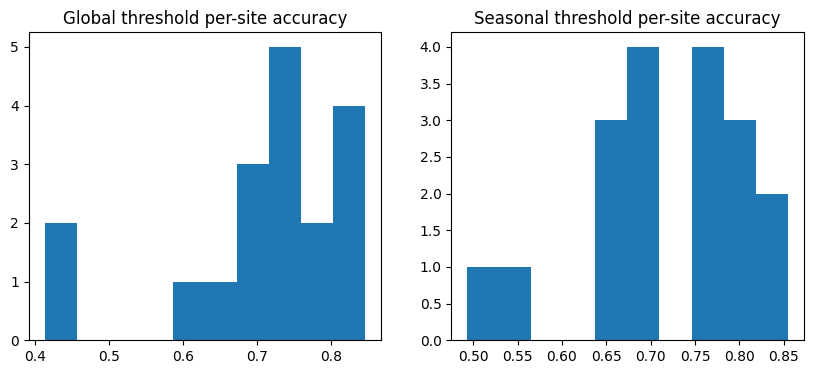

In [59]:
# pick best model (likely rank)
balance_col = "balance_rank_logratio"

# global
site_acc_global, _ = evaluate_threshold_balanced(
    test,
    balance_col,
    site_thresh_all[site_thresh_all["balance_col"] == balance_col][["region", "threshold"]],
    ["region"],
)

# seasonal
site_acc_seasonal, _ = evaluate_threshold_balanced(
    test,
    balance_col,
    site_season_thresh_all[site_season_thresh_all["balance_col"] == balance_col][
        ["region", "season", "threshold"]
    ],
    ["region", "season"],
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(site_acc_global["balanced_acc"], bins=10)
axes[0].set_title("Global threshold per-site accuracy")

axes[1].hist(site_acc_seasonal["balanced_acc"], bins=10)
axes[1].set_title("Seasonal threshold per-site accuracy")

plt.show()

In [60]:
daily[(daily.region == 15) & (daily.date.between("2023-12-20", "2024-01-31"))][
    [
        "date",
        "p_open",
        "tide_range",
        "wave_energy_cross_p90",
        "wave_energy_along_p90",
        "streamflow_max",
    ]
].round(2)

/var/folders/pr/1dt1qk511zdgzhfy1xskpqm00000gn/T/ipykernel_84770/2215029850.py:5: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ].round(2)


,date,p_open,tide_range,wave_energy_cross_p90,wave_energy_along_p90,streamflow_max
7995,2023-12-20,1.00,1.16,7.85,1.61,16.40
7996,2023-12-21,1.00,1.27,13.95,3.66,16.20
7997,2023-12-22,1.00,1.58,22.49,4.14,20.62
7998,2023-12-23,1.00,1.85,13.68,2.83,90.55
7999,2023-12-24,1.00,2.02,9.62,2.69,50.48
8000,2023-12-25,1.00,2.12,10.91,0.93,27.42
8001,2023-12-26,1.00,2.13,13.13,0.31,20.18
8002,2023-12-27,0.84,2.06,8.40,0.41,20.40
8003,2023-12-28,0.69,2.01,35.83,2.55,19.52
8004,2023-12-29,0.53,1.85,74.90,8.16,16.58


In [61]:
site_df2 = site_df.sort_values(["region", "date"])

site_df2["flow_roll_7d"] = (
    site_df2.groupby("region")["streamflow_max"].rolling(7).sum().reset_index(level=0, drop=True)
)

site_df2["flow_roll_14d"] = (
    site_df2.groupby("region")["streamflow_max"].rolling(14).sum().reset_index(level=0, drop=True)
)
eps = 1e-4

site_df2["flow_roll_rank"] = site_df2.groupby("region")["flow_roll_7d"].rank(
    method="average", pct=True
)

site_df2["flow_roll_rank_clip"] = site_df2["flow_roll_rank"].clip(eps, 1 - eps)

site_df2["balance_mem"] = (
    np.log(site_df2["wave_rank_clip"])
    # - np.log(site_df2["flow_rank_clip"])
    - np.log(site_df2["flow_roll_rank_clip"])
)

site_thresh_mem = estimate_thresholds(
    site_df2,
    group_cols=["region"],
    balance_col="balance_mem",
    open_thresh=0.7,
    closed_thresh=0.3,
    min_each_class=10,
)

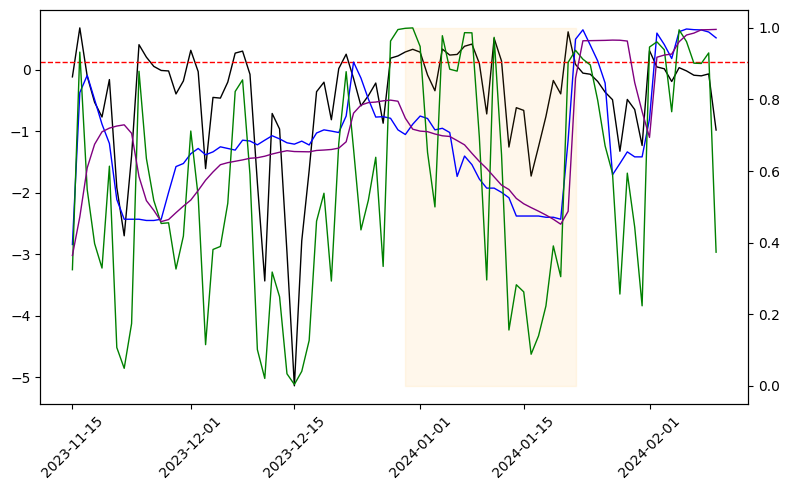

In [62]:
A = site_df2.merge(
    site_thresh_mem[["region", "threshold"]],
    on="region",
    how="inner",
).copy()

A = A[A.region == 15].copy()
sub = A[A.date.between("2023-11-15", "2024-02-10")].copy().sort_values("date")

fig, ax = plt.subplots(1, 1, figsize=(8, 5))

# new balance
ax.plot(sub["date"], sub["balance_mem"], color="black", linewidth=1)
ax.axhline(sub["threshold"].iloc[0], color="red", linestyle="--", linewidth=1)

ax2 = ax.twinx()

mask = sub["p_open"] < 0.5
ax2.fill_between(sub["date"], 0, 1, where=mask, color="orange", alpha=0.08)

ax2.plot(sub["date"], sub["flow_rank"], color="blue", linewidth=1)
ax2.plot(sub["date"], sub["wave_rank"], color="green", linewidth=1)
ax2.plot(sub["date"], sub["flow_roll_rank"], color="purple", linewidth=1)

ax2.set_ylim(-0.05, 1.05)

ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [63]:
# Starting from site_df with:
# region, date, season, p_open, balance_rank_logratio, flow_rank, wave_rank

df = site_df.copy()

df["state"] = np.select(
    [
        df["p_open"] >= 0.7,
        df["p_open"] <= 0.3,
    ],
    [
        "open",
        "closed",
    ],
    default="uncertain",
)

state_df = df[df["state"].isin(["open", "closed"])].copy()

state_summary = state_df.groupby(["region", "state"], as_index=False).agg(
    n=("p_open", "size"),
    balance_med=("balance_rank_logratio", "median"),
    balance_q25=("balance_rank_logratio", lambda s: s.quantile(0.25)),
    balance_q75=("balance_rank_logratio", lambda s: s.quantile(0.75)),
    flow_rank_med=("flow_rank", "median"),
    wave_rank_med=("wave_rank", "median"),
)

state_summary.head()

,region,state,n,balance_med,balance_q25,balance_q75,flow_rank_med,wave_rank_med
0,11,closed,156,0.095596,-0.335987,0.594130,0.577541,0.614091
1,11,open,2444,-0.001778,-0.522843,0.492188,0.491878,0.484511
2,14,closed,566,0.912300,0.225794,1.386293,0.170759,0.474688
3,14,open,2047,-0.149111,-0.813159,0.273907,0.612014,0.504345
4,15,closed,181,0.249584,-0.422857,1.138859,0.186091,0.522736


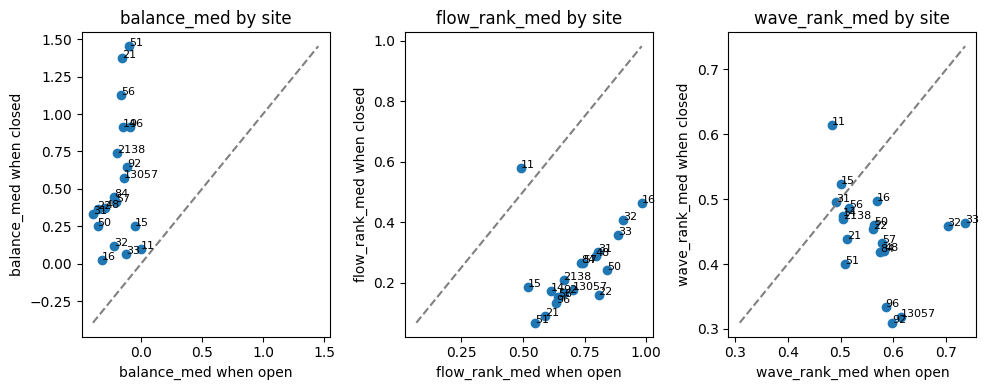

In [67]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 4))

for ax, value in zip(axes, ["balance_med", "flow_rank_med", "wave_rank_med"]):
    wide = state_summary.pivot(
        index="region",
        columns="state",
        values=value,
    ).dropna()

    wide["state_separation"] = wide["closed"] - wide["open"]

    ax.scatter(wide["open"], wide["closed"])

    lims = [
        min(wide["open"].min(), wide["closed"].min()),
        max(wide["open"].max(), wide["closed"].max()),
    ]
    ax.plot(lims, lims, color="gray", linestyle="--")

    for region, row in wide.iterrows():
        ax.text(row["open"], row["closed"], str(region), fontsize=8)

    ax.set_xlabel(f"{value} when open")
    ax.set_ylabel(f"{value} when closed")
    ax.set_title(f"{value} by site")

fig.tight_layout()
plt.savefig("/Users/kyledorman/Desktop/rank_when_close.png")
plt.show()

In [65]:
df = site_df.copy()
df = df[df.region != 12103].copy()
df = df.sort_values(["region", "date"]).reset_index(drop=True)

days = 7
min_open = 0.7
min_closed = 0.3

df[f"flow_roll_{days}d"] = (
    df.groupby("region")["streamflow_max"].rolling(days).max().reset_index(level=0, drop=True)
)

df[f"wave_roll_{days}d"] = (
    df.groupby("region")["wave_energy_cross_p90"]
    .rolling(days)
    .max()
    .reset_index(level=0, drop=True)
)
df[f"tide_roll_{days}d"] = (
    df.groupby("region")["tide_range"].rolling(days).mean().reset_index(level=0, drop=True)
)

df["flow_rank_smooth"] = df.groupby("region")[f"flow_roll_{days}d"].rank(pct=True)
df["wave_rank_smooth"] = df.groupby("region")[f"wave_roll_{days}d"].rank(pct=True)
df["tide_rank_smooth"] = df.groupby("region")[f"tide_roll_{days}d"].rank(pct=True)

df["p_open_prev"] = df.groupby("region")["p_open"].shift(days)
df["state_prev"] = np.select(
    [
        df["p_open_prev"] >= min_open,
        df["p_open_prev"] <= min_closed,
    ],
    [
        "open",
        "closed",
    ],
    default="uncertain",
)

df["state"] = np.select(
    [
        df["p_open"] >= min_open,
        df["p_open"] <= min_closed,
    ],
    [
        "open",
        "closed",
    ],
    default="uncertain",
)

df["transition"] = "none"
df.loc[(df["state_prev"] == "closed") & (df["state"] == "open"), "transition"] = "opening"
df.loc[(df["state_prev"] == "open") & (df["state"] == "closed"), "transition"] = "closing"

trans = df[df["transition"].isin(["opening", "closing"])].copy()

trans_summary = trans.groupby(["region", "transition"], as_index=False).agg(
    n=("p_open", "size"),
    balance_med=("balance_rank_logratio", "median"),
    flow_rank_med=("flow_rank_smooth", "median"),
    wave_rank_med=("wave_rank_smooth", "median"),
    tide_rank_med=("tide_rank_smooth", "median"),
)

trans_summary.head(6)

,region,transition,n,balance_med,flow_rank_med,wave_rank_med,tide_rank_med
0,11,closing,34,0.113488,0.512306,0.831882,0.398334
1,11,opening,29,0.386181,0.458160,0.625142,0.622870
2,14,closing,17,0.579641,0.356683,0.920485,0.204847
3,14,opening,20,-0.114217,0.760318,0.843241,0.654108
4,15,closing,13,0.574465,0.168518,0.762543,0.277288
5,15,opening,16,-0.808377,0.958254,0.707966,0.733818


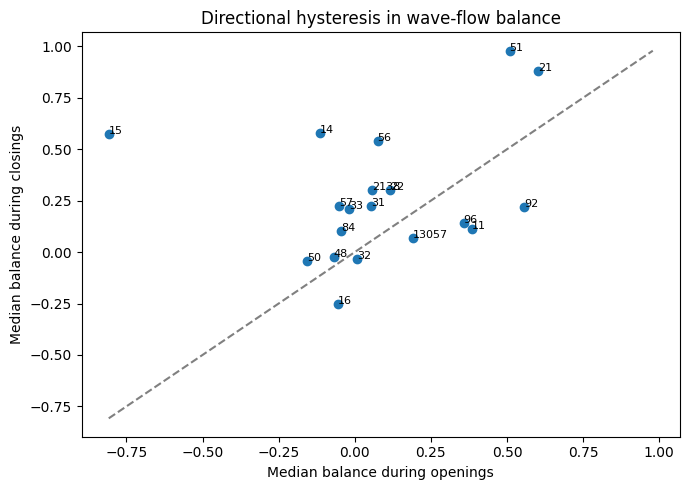

count    19.000000
mean      0.184901
std       0.397229
min      -0.338819
25%      -0.082150
50%       0.171493
75%       0.278465
max       1.382843
Name: hysteresis_gap, dtype: float64

In [66]:
trans_wide = trans_summary.pivot(
    index="region",
    columns="transition",
    values="balance_med",
).dropna()

trans_wide["hysteresis_gap"] = trans_wide["closing"] - trans_wide["opening"]

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(trans_wide["opening"], trans_wide["closing"])

lims = [
    min(trans_wide["opening"].min(), trans_wide["closing"].min()),
    max(trans_wide["opening"].max(), trans_wide["closing"].max()),
]
ax.plot(lims, lims, color="gray", linestyle="--")

for region, row in trans_wide.iterrows():
    ax.text(row["opening"], row["closing"], str(region), fontsize=8)

ax.set_xlabel("Median balance during openings")
ax.set_ylabel("Median balance during closings")
ax.set_title("Directional hysteresis in wave-flow balance")

plt.tight_layout()
plt.show()

trans_wide["hysteresis_gap"].describe()

In [68]:
model_df = df.copy()
model_df = df[
    df["state"].isin(["open", "closed"]) & df["state_prev"].isin(["open", "closed"])
].copy()

model_df = model_df.dropna(
    subset=[
        "flow_rank_smooth",
        "wave_rank_smooth",
        "tide_rank_smooth",
        "state_prev",
        "state",
        "region",
    ]
).copy()

model_df["is_open"] = (model_df["state"] == "open").astype(int)

# binary current state, only confident states
model_df = model_df[model_df["state"].isin(["open", "closed"])].copy()
model_df = model_df[model_df["state_prev"].isin(["open", "closed"])].copy()

model_df["is_open"] = (model_df["state"] == "open").astype(int)

m = smf.logit(
    "is_open ~ flow_rank_smooth * wave_rank_smooth * C(state_prev)+ C(region)",
    data=model_df,
).fit()

print(m.summary())

Optimization terminated successfully.
         Current function value: 0.142325
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                is_open   No. Observations:                45530
Model:                          Logit   Df Residuals:                    45504
Method:                           MLE   Df Model:                           25
Date:                Mon, 27 Apr 2026   Pseudo R-squ.:                  0.7920
Time:                        10:30:07   Log-Likelihood:                -6480.0
converged:                       True   LL-Null:                       -31151.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                              coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------
Intercept         

In [69]:
params = m.params

# find baseline region (the one NOT in C(region))
all_regions = sorted(model_df["region"].unique())
coef_regions = [
    int(k.split("[T.")[1].rstrip("]")) for k in params.index if k.startswith("C(region)")
]

baseline_region = list(set(all_regions) - set(coef_regions))[0]

site_intercepts = []

for r in all_regions:
    if r == baseline_region:
        intercept = params["Intercept"]
    else:
        intercept = params["Intercept"] + params[f"C(region)[T.{r}]"]

    site_intercepts.append(
        {
            "region": r,
            "intercept": intercept,
        }
    )

site_intercepts = pd.DataFrame(site_intercepts)
site_intercepts

site_mean = site_df.groupby("region", as_index=False).agg(mean_p_open=("p_open", "mean"))

site_summary = site_intercepts.merge(site_mean, on="region", how="inner")
site_summary

,region,intercept,mean_p_open
0,11,-3.498046,0.931294
1,14,-3.925777,0.779377
2,15,-3.292922,0.921044
3,16,-9.219936,0.039285
4,21,-3.566430,0.824295
5,22,-6.437867,0.380958
6,31,-6.137032,0.391423
7,32,-7.766360,0.161583
8,33,-7.886225,0.112407
9,48,-6.350943,0.413861


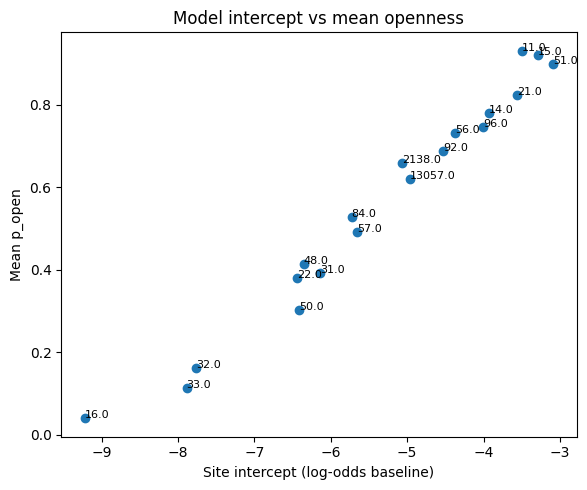

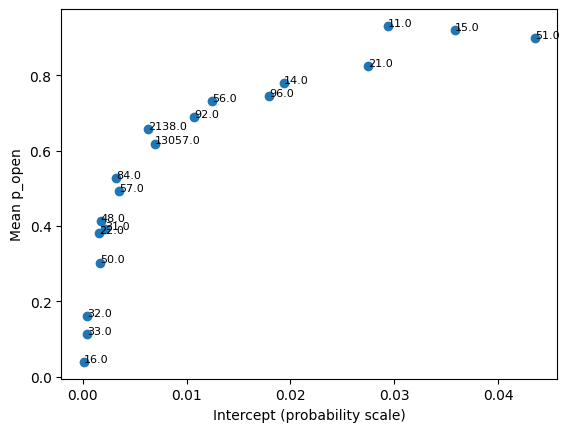

In [70]:
site_summary["intercept_prob"] = 1 / (1 + np.exp(-site_summary["intercept"]))

fig, ax = plt.subplots(figsize=(6, 5))

ax.scatter(
    site_summary["intercept"],
    site_summary["mean_p_open"],
)

for _, row in site_summary.iterrows():
    ax.text(
        row["intercept"],
        row["mean_p_open"],
        str(row["region"]),
        fontsize=8,
    )

ax.set_xlabel("Site intercept (log-odds baseline)")
ax.set_ylabel("Mean p_open")
ax.set_title("Model intercept vs mean openness")

plt.tight_layout()
plt.show()

plt.scatter(site_summary["intercept_prob"], site_summary["mean_p_open"])

for _, row in site_summary.iterrows():
    plt.text(
        row["intercept_prob"],
        row["mean_p_open"],
        str(row["region"]),
        fontsize=8,
    )

plt.xlabel("Intercept (probability scale)")
plt.ylabel("Mean p_open")
plt.show()

# Driver Instantaneous vs Seasonal Response

> The model captures the underlying driver-response relationship, but this relationship only emerges clearly when averaged over time due to strong persistence and stochasticity at shorter timescales.

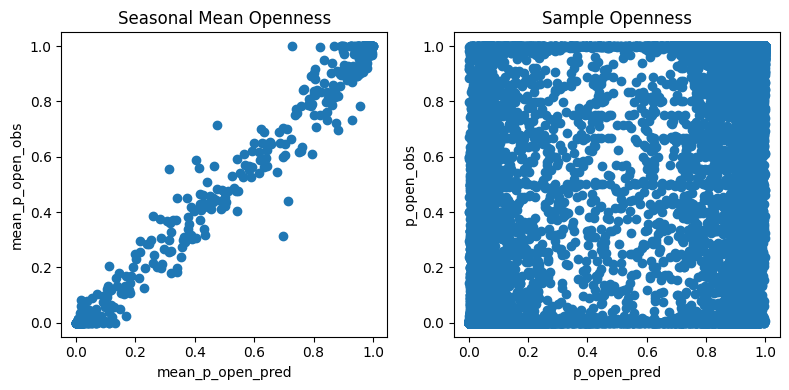

Daily R^2: 0.822
Seasonal R^2: 0.981


In [71]:
from sklearn.metrics import r2_score

record_df = site_df.copy()

record_df["flow_roll_5d"] = (
    record_df.groupby("region")["streamflow_max"].rolling(5).mean().reset_index(level=0, drop=True)
)

record_df["wave_roll_5d"] = (
    record_df.groupby("region")["wave_energy_cross_p90"]
    .rolling(5)
    .max()
    .reset_index(level=0, drop=True)
)

record_df["flow_rank_smooth"] = record_df.groupby("region")["flow_roll_5d"].rank(pct=True)

record_df["wave_rank_smooth"] = record_df.groupby("region")["wave_roll_5d"].rank(pct=True)

record_df["p_open_prev"] = record_df.groupby("region")["p_open"].shift(5)
record_df["state_prev"] = pd.Categorical(
    np.where(record_df["p_open_prev"] > 0.4, "open", "closed"),
    categories=["closed", "open"],  # match training ordering
)

record_df = record_df[
    [
        "region",
        "year",
        "month",
        "date",
        "season",
        "wy_season",
        "water_year",
        "p_open",
        "p_open_prev",
        "state_prev",
        "wave_rank_smooth",
        "flow_rank_smooth",
    ]
]
record_df.dropna(inplace=True)
record_df = record_df[record_df.region != 12103].copy()

record_df["p_open_hat"] = m.predict(record_df)


seasonal_summary = record_df.groupby(["region", "year", "season"], as_index=False).agg(
    mean_p_open_obs=("p_open", "mean"),
    mean_p_open_pred=("p_open_hat", "mean"),
    var_p_open=("p_open", "var"),
    mean_flow=("flow_rank_smooth", "mean"),
    mean_wave=("wave_rank_smooth", "mean"),
)
fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(8, 4))
axes[0].scatter(
    x=seasonal_summary["mean_p_open_pred"],
    y=seasonal_summary["mean_p_open_obs"],
)
axes[0].set_title("Seasonal Mean Openness")
axes[0].set_xlabel("mean_p_open_pred")
axes[0].set_ylabel("mean_p_open_obs")
axes[1].scatter(
    x=record_df["p_open_hat"],
    y=record_df["p_open"],
)
axes[1].set_title("Sample Openness")
axes[1].set_xlabel("p_open_pred")
axes[1].set_ylabel("p_open_obs")
fig.tight_layout()
plt.show()

print("Daily R^2:", round(r2_score(record_df["p_open"], record_df["p_open_hat"]), 3))
print(
    "Seasonal R^2:",
    round(r2_score(seasonal_summary["mean_p_open_obs"], seasonal_summary["mean_p_open_pred"]), 3),
)

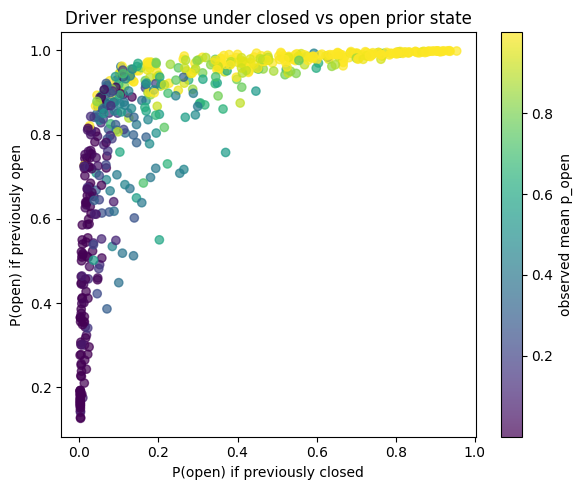

In [73]:
cf = record_df.copy()

cf_closed = cf.copy()
cf_closed["state_prev"] = "closed"
cf["p_open_if_closed"] = m.predict(cf_closed)

cf_open = cf.copy()
cf_open["state_prev"] = "open"
cf["p_open_if_open"] = m.predict(cf_open)

cf["persistence_gap"] = cf["p_open_if_open"] - cf["p_open_if_closed"]

seasonal_cf = cf.groupby(["region", "year", "season"], as_index=False).agg(
    obs_open=("p_open", "mean"),
    driver_open_from_closed=("p_open_if_closed", "mean"),
    driver_open_from_open=("p_open_if_open", "mean"),
    p_open_mean=("p_open", "mean"),
    persistence_gap=("persistence_gap", "mean"),
    flow=("flow_rank_smooth", "mean"),
    wave=("wave_rank_smooth", "mean"),
)

fig, ax = plt.subplots(figsize=(6, 5))

ax.scatter(
    seasonal_cf["driver_open_from_closed"],
    seasonal_cf["driver_open_from_open"],
    c=seasonal_cf["obs_open"],
    alpha=0.7,
)

ax.set_xlabel("P(open) if previously closed")
ax.set_ylabel("P(open) if previously open")
ax.set_title("Driver response under closed vs open prior state")

plt.colorbar(ax.collections[0], label="observed mean p_open")
plt.tight_layout()
plt.savefig("/Users/kyledorman/Desktop/resp_v_state.png")
plt.show()

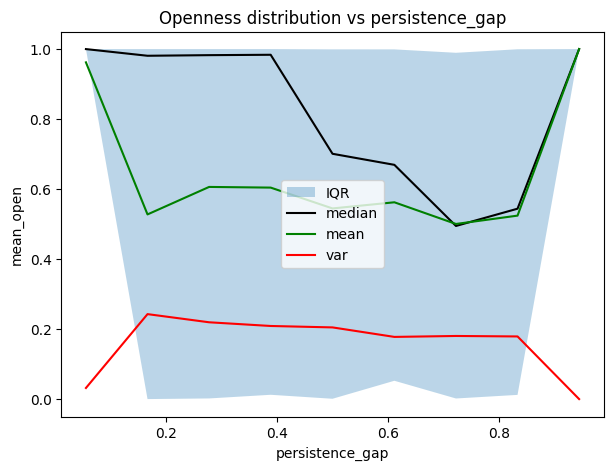

In [74]:
import numpy as np
import pandas as pd

monthly_cf = cf.groupby(["region", "water_year", "month"], as_index=False).agg(
    mean_open=("p_open", "mean"),
    open_from_closed=("p_open_if_closed", "mean"),
    open_from_open=("p_open_if_open", "mean"),
    persistence_gap=("persistence_gap", "mean"),
)

# define bins
bins = np.linspace(0, 1, 10)
monthly_cf["gap_bin"] = pd.cut(monthly_cf["persistence_gap"], bins)

binned = (
    monthly_cf.groupby("gap_bin")
    .agg(
        q10=("mean_open", lambda s: s.quantile(0.1)),
        q25=("mean_open", lambda s: s.quantile(0.25)),
        median=("mean_open", "median"),
        mean=("mean_open", "mean"),
        q75=("mean_open", lambda s: s.quantile(0.75)),
        q90=("mean_open", lambda s: s.quantile(0.9)),
        n=("mean_open", "size"),
    )
    .reset_index()
)

# get bin centers
binned["x"] = binned["gap_bin"].apply(lambda x: x.mid)

plt.figure(figsize=(7, 5))

# IQR band
plt.fill_between(binned["x"], binned["q25"], binned["q75"], alpha=0.3, label="IQR")

# outer band (optional, very helpful)
# plt.fill_between(
#     binned["x"],
#     binned["q10"],
#     binned["q90"],
#     alpha=0.15,
#     label="10–90%"
# )
binned["var"] = monthly_cf.groupby("gap_bin")["mean_open"].var().values

# median
plt.plot(binned["x"], binned["median"], color="black", label="median")
plt.plot(binned["x"], binned["mean"], color="green", label="mean")
plt.plot(binned["x"], binned["var"], color="red", label="var")

plt.xlabel("persistence_gap")
plt.ylabel("mean_open")
plt.title("Openness distribution vs persistence_gap")
plt.legend()
plt.show()

# Persistance Gap by Season/Water Year
> When forcing is strong (winter), the system is driver-controlled. When forcing is weak (summer), the system is state-controlled.

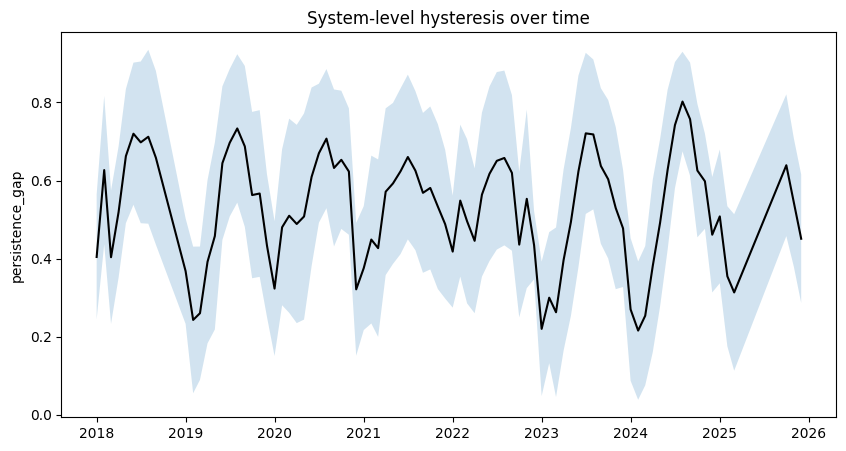

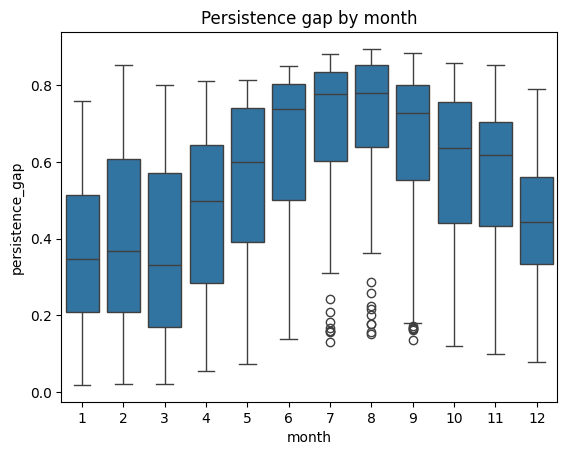

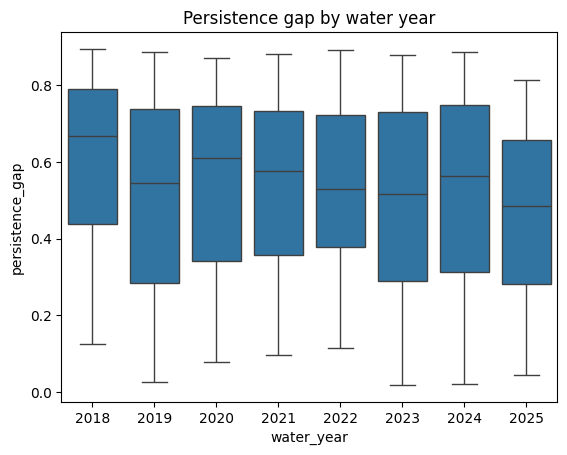

In [75]:
monthly_gap = cf.groupby(["region", "water_year", "month"], as_index=False).agg(
    persistence_gap=("persistence_gap", "mean"),
    open_from_closed=("p_open_if_closed", "mean"),
    open_from_open=("p_open_if_open", "mean"),
)
monthly_gap_mean = monthly_gap.groupby(["water_year", "month"], as_index=False).agg(
    persistence_gap=("persistence_gap", "mean"),
    gap_std=("persistence_gap", "std"),
)
monthly_gap_mean["time"] = pd.to_datetime(
    dict(year=monthly_gap_mean.water_year, month=monthly_gap_mean.month, day=1)
)

plt.figure(figsize=(10, 5))

plt.plot(monthly_gap_mean["time"], monthly_gap_mean["persistence_gap"], color="black")

plt.fill_between(
    monthly_gap_mean["time"],
    monthly_gap_mean["persistence_gap"] - monthly_gap_mean["gap_std"],
    monthly_gap_mean["persistence_gap"] + monthly_gap_mean["gap_std"],
    alpha=0.2,
)

plt.ylabel("persistence_gap")
plt.title("System-level hysteresis over time")
plt.show()

plt.figure()
sns.boxplot(data=monthly_gap, x="month", y="persistence_gap")

plt.title("Persistence gap by month")
plt.show()

plt.figure()
sns.boxplot(data=monthly_gap, x="water_year", y="persistence_gap")

plt.title("Persistence gap by water year")
plt.show()

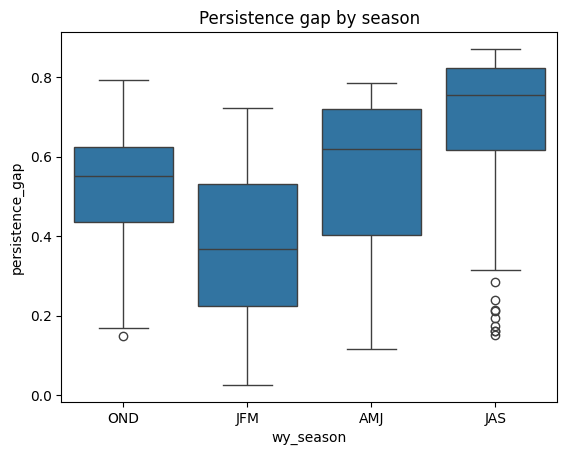

In [76]:
season_order = ["OND", "JFM", "AMJ", "JAS"]

seasonal_gap = cf.groupby(["region", "water_year", "wy_season"], as_index=False).agg(
    persistence_gap=("persistence_gap", "mean"),
)

seasonal_gap_mean = seasonal_gap.groupby(["water_year", "wy_season"], as_index=False).agg(
    persistence_gap=("persistence_gap", "mean"),
)

seasonal_gap["wy_season"] = pd.Categorical(
    seasonal_gap["wy_season"], categories=season_order, ordered=True
)
sns.boxplot(data=seasonal_gap, x="wy_season", y="persistence_gap")

plt.title("Persistence gap by season")
plt.show()

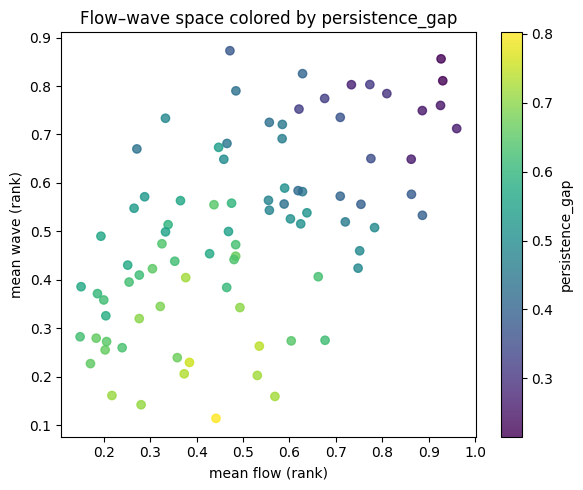

In [77]:
# Flow and gap are inversly correlated

monthly_flow = cf.groupby(["year", "month"], as_index=False).agg(
    flow=("flow_rank_smooth", "mean"),
    wave=("wave_rank_smooth", "mean"),
    persistence_gap=("persistence_gap", "mean"),
)
fig, ax = plt.subplots(figsize=(6, 5))

sc = ax.scatter(
    monthly_flow["flow"],
    monthly_flow["wave"],
    c=monthly_flow["persistence_gap"],
    cmap="viridis",
    alpha=0.8,
)

ax.set_xlabel("mean flow (rank)")
ax.set_ylabel("mean wave (rank)")
ax.set_title("Flow–wave space colored by persistence_gap")

plt.colorbar(sc, label="persistence_gap")
plt.tight_layout()
plt.show()

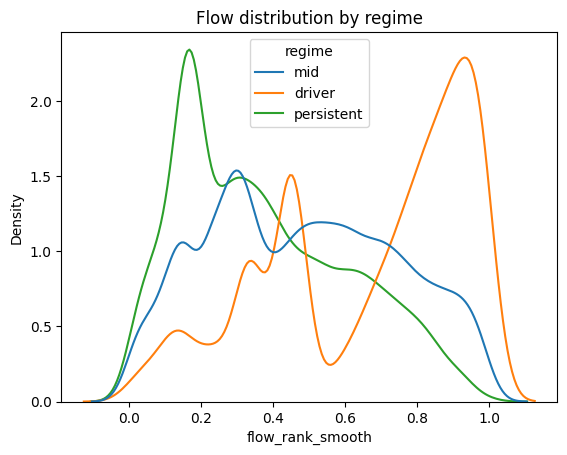

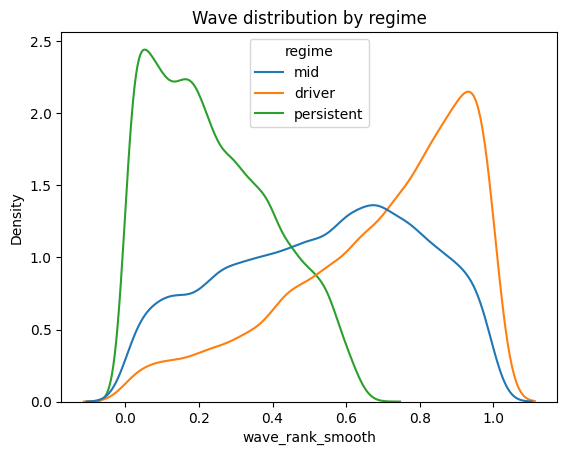

In [82]:
df = cf.copy()

# define quantiles instead of arbitrary thresholds
low_thresh = df["persistence_gap"].quantile(0.25)
high_thresh = df["persistence_gap"].quantile(0.75)

df["regime"] = "mid"
df.loc[df["persistence_gap"] <= low_thresh, "regime"] = "driver"
df.loc[df["persistence_gap"] >= high_thresh, "regime"] = "persistent"

import seaborn as sns

plt.figure()
sns.kdeplot(data=df, x="flow_rank_smooth", hue="regime", common_norm=False)
plt.title("Flow distribution by regime")
plt.savefig("/Users/kyledorman/Desktop/flow_regime.png")
plt.show()

plt.figure()
sns.kdeplot(data=df, x="wave_rank_smooth", hue="regime", common_norm=False)
plt.title("Wave distribution by regime")
plt.savefig("/Users/kyledorman/Desktop/wave_regime.png")
plt.show()

In [80]:
import numpy as np
import pandas as pd


def simulate_expected_path(
    df_region: pd.DataFrame,
    model,
    initial_p_open: float | None = None,
) -> pd.DataFrame:
    sub = df_region.sort_values("date").copy().reset_index(drop=True)

    if initial_p_open is None:
        initial_p_open = float(sub["p_open"].iloc[0])

    p_sim = np.zeros(len(sub))
    p_sim[0] = initial_p_open

    for i in range(1, len(sub)):
        row_closed = sub.iloc[[i]].copy()
        row_open = sub.iloc[[i]].copy()

        row_closed["state_prev"] = "closed"
        row_open["state_prev"] = "open"

        p_if_closed = float(model.predict(row_closed).iloc[0])
        p_if_open = float(model.predict(row_open).iloc[0])

        # Propagate expected state:
        # P(open_t) = P(open_t | closed_prev) * P(closed_prev)
        #           + P(open_t | open_prev)   * P(open_prev)
        p_sim[i] = (1 - p_sim[i - 1]) * p_if_closed + p_sim[i - 1] * p_if_open

    out = sub.copy()
    out["p_open_sim"] = p_sim
    return out


sim_frames = []
import tqdm

for region, sub in tqdm.tqdm(model_df.groupby("region"), total=len(model_df.region.unique())):
    sim_frames.append(
        simulate_expected_path(
            df_region=sub,
            model=m,
            initial_p_open=float(sub.sort_values("date")["p_open"].iloc[0]),
        )
    )

sim_df = pd.concat(sim_frames, ignore_index=True)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19/19 [02:13<00:00,  7.00s/it]


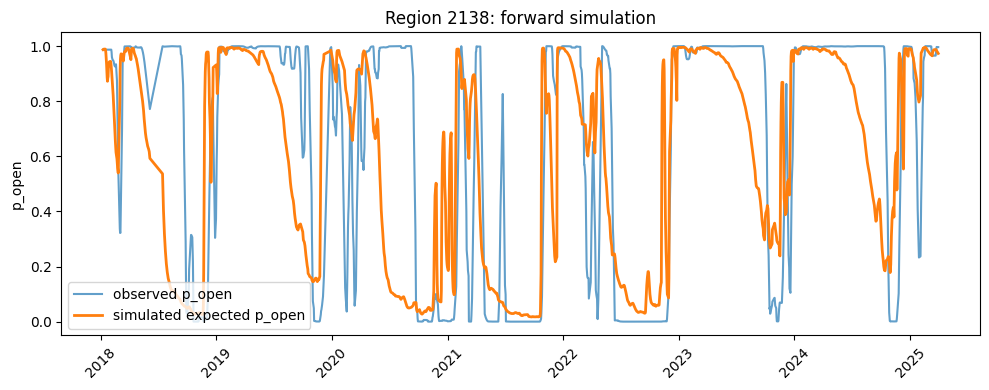

In [83]:
r = 2138

sub = sim_df[sim_df["region"] == r].sort_values("date").reset_index()
sub["p_open_smooth"] = (
    sub.set_index("date")["p_open"].rolling("14D").mean().reset_index(level=0, drop=True)
)

plt.figure(figsize=(10, 4))
plt.plot(sub["date"], sub["p_open_smooth"], label="observed p_open", alpha=0.7)
plt.plot(sub["date"], sub["p_open_sim"], label="simulated expected p_open", linewidth=2)
plt.legend(loc="lower left")
plt.title(f"Region {r}: forward simulation")
plt.ylabel("p_open")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("/Users/kyledorman/Desktop/2138.png")
plt.show()

In [ ]:
def simulate_mc_paths_fast(
    df_region: pd.DataFrame,
    model,
    n_sims: int = 1000,
    initial_state: str | None = None,
    random_seed: int = 42,
    rolling_window: int = 7,
) -> pd.DataFrame:
    rng = np.random.default_rng(random_seed)

    sub = df_region.sort_values("date").copy().reset_index(drop=True)

    if initial_state is None:
        initial_state = "open" if sub["p_open"].iloc[0] >= 0.5 else "closed"

    paths = np.zeros((n_sims, len(sub)), dtype=np.int8)
    paths[:, 0] = 1 if initial_state == "open" else 0

    closed_rows = sub.copy()
    closed_rows["state_prev"] = "closed"
    p_if_closed = model.predict(closed_rows).to_numpy()

    open_rows = sub.copy()
    open_rows["state_prev"] = "open"
    p_if_open = model.predict(open_rows).to_numpy()

    for i in range(1, len(sub)):
        prev_open = paths[:, i - 1].astype(bool)
        p_open = np.where(prev_open, p_if_open[i], p_if_closed[i])
        paths[:, i] = rng.random(n_sims) < p_open

    # Raw daily path summaries
    out = sub.copy()
    out["mc_mean"] = paths.mean(axis=0)
    out["mc_q05"] = np.quantile(paths, 0.05, axis=0)
    out["mc_q25"] = np.quantile(paths, 0.25, axis=0)
    out["mc_q75"] = np.quantile(paths, 0.75, axis=0)
    out["mc_q95"] = np.quantile(paths, 0.95, axis=0)

    # Rolling path summaries: smooth each simulated path first, then take quantiles.
    paths_roll = (
        pd.DataFrame(paths.T).rolling(window=rolling_window, min_periods=1).mean().to_numpy().T
    )

    out[f"mc_roll{rolling_window}_mean"] = paths_roll.mean(axis=0)
    out[f"mc_roll{rolling_window}_q05"] = np.quantile(paths_roll, 0.05, axis=0)
    out[f"mc_roll{rolling_window}_q25"] = np.quantile(paths_roll, 0.25, axis=0)
    out[f"mc_roll{rolling_window}_q75"] = np.quantile(paths_roll, 0.75, axis=0)
    out[f"mc_roll{rolling_window}_q95"] = np.quantile(paths_roll, 0.95, axis=0)

    # Rolling observed p_open for comparable visualization.
    out[f"p_open_roll{rolling_window}"] = (
        out["p_open"].rolling(window=rolling_window, min_periods=1).mean()
    )

    return out

In [ ]:
mc_frames = []

for region, sub in tqdm.tqdm(model_df.groupby("region"), total=model_df["region"].nunique()):
    mc_frames.append(
        simulate_mc_paths_fast(
            df_region=sub,
            model=m,
            n_sims=1000,
            initial_state=None,
            random_seed=int(region),
            rolling_window=14,
        )
    )

mc_df = pd.concat(mc_frames, ignore_index=True)

mc_df.head()

In [ ]:
r = 84
w = 14

sub = mc_df[mc_df["region"] == r].sort_values("date").copy()

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    sub["date"],
    sub[f"p_open_roll{w}"],
    label=f"observed p_open ({w}d mean)",
    alpha=0.6,
    color="blue",
)
ax.plot(sub["date"], sub[f"mc_roll{w}_mean"], label=f"MC mean ({w}d mean)", color="orange")

# ax.fill_between(
#     sub["date"],
#     sub[f"mc_roll{w}_q05"],
#     sub[f"mc_roll{w}_q95"],
#     alpha=0.15,
#     label="5–95%",
#     color="red",
# )

ax.fill_between(
    sub["date"],
    sub[f"mc_roll{w}_q25"],
    sub[f"mc_roll{w}_q75"],
    alpha=0.25,
    label="25–75%",
    color="orange",
)

ax.set_ylim(-0.05, 1.05)
ax.legend(loc="lower left")
ax.set_title(f"Region {r}")
plt.tight_layout()
plt.show()

In [ ]:
w = 14

mc_df["inside_50"] = (mc_df[f"p_open_roll{w}"] >= mc_df[f"mc_roll{w}_q25"]) & (
    mc_df[f"p_open_roll{w}"] <= mc_df[f"mc_roll{w}_q75"]
)

mc_df["inside_90"] = (mc_df[f"p_open_roll{w}"] >= mc_df[f"mc_roll{w}_q05"]) & (
    mc_df[f"p_open_roll{w}"] <= mc_df[f"mc_roll{w}_q95"]
)

mc_df["error"] = mc_df[f"p_open_roll{w}"] - mc_df[f"mc_roll{w}_mean"]
mc_df["abs_error"] = mc_df["error"].abs()
mc_df["sq_error"] = mc_df["error"] ** 2

print("50% coverage:", mc_df["inside_50"].mean())
print("90% coverage:", mc_df["inside_90"].mean())

cov_region = (
    mc_df.groupby("region", as_index=False)
    .agg(
        cov_50=("inside_50", "mean"),
        cov_90=("inside_90", "mean"),
        n=("inside_50", "size"),
        mae=("abs_error", "mean"),
        rmse=("sq_error", lambda s: np.sqrt(s.mean())),
        bias=("error", "mean"),
    )
    .sort_values("cov_50")
)

fig, ax = plt.subplots(figsize=(7, 4))

ax.scatter(cov_region["cov_50"], cov_region["cov_90"])

for _, row in cov_region.iterrows():
    ax.text(row["cov_50"], row["cov_90"], str(row["region"]), fontsize=8)

# reference lines
ax.axvline(0.5, linestyle="--", color="gray")
ax.axhline(0.9, linestyle="--", color="gray")

ax.set_xlabel("50% coverage")
ax.set_ylabel("90% coverage")
ax.set_title("Coverage by estuary")

plt.tight_layout()
plt.show()

cov_region.sort_values("cov_50").plot.bar(x="region", y=["cov_50", "cov_90"], figsize=(8, 4))
plt.axhline(0.5, linestyle="--", color="gray")
plt.axhline(0.9, linestyle="--", color="gray")
plt.ylabel("coverage")
plt.title("Coverage per region")
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(cov_region["region"].astype(str), cov_region["mae"])

ax.set_xlabel("region")
ax.set_ylabel("MAE")
ax.set_title("Mean absolute error by region")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))

sc = ax.scatter(
    cov_region["cov_50"],
    cov_region["cov_90"],
    c=cov_region["mae"],  # color = error
    cmap="viridis",
    s=80,
)

# labels
for _, row in cov_region.iterrows():
    ax.text(row["cov_50"], row["cov_90"], str(row["region"]), fontsize=8)

# reference lines (ideal calibration)
ax.axvline(0.5, linestyle="--", color="gray")
ax.axhline(0.9, linestyle="--", color="gray")

ax.set_xlabel("50% coverage")
ax.set_ylabel("90% coverage")
ax.set_title("Calibration vs Error (color = MAE)")

plt.colorbar(sc, label="MAE")
plt.tight_layout()
plt.show()

In [ ]:
sim_df["error"] = sim_df["p_open"] - sim_df["p_open_sim"]
sim_df["abs_error"] = sim_df["error"].abs()
sim_df["sq_error"] = sim_df["error"] ** 2

region_err = (
    sim_df.groupby("region", as_index=False)
    .agg(
        mae=("abs_error", "mean"),
        rmse=("sq_error", lambda s: np.sqrt(s.mean())),
        bias=("error", "mean"),
        n=("error", "size"),
    )
    .sort_values("mae", ascending=False)
)

plt.figure(figsize=(6, 4))
plt.bar(region_err["region"].astype(str), region_err["mae"])
plt.xticks(rotation=45)
plt.ylabel("MAE")
plt.title("Error by region")
plt.show()

year_err = sim_df.groupby("water_year", as_index=False).agg(
    mae=("abs_error", "mean"),
    rmse=("sq_error", lambda s: np.sqrt(s.mean())),
    bias=("error", "mean"),
)

plt.plot(year_err["water_year"], year_err["mae"], marker="o")
plt.ylabel("MAE")
plt.title("Error by water year")
plt.show()

sim_df["month"] = pd.to_datetime(sim_df["date"]).dt.month

month_err = sim_df.groupby("month", as_index=False).agg(
    mae=("abs_error", "mean"),
    rmse=("sq_error", lambda s: np.sqrt(s.mean())),
    bias=("error", "mean"),
)

plt.plot(month_err["month"], month_err["mae"], marker="o")
plt.xlabel("month")
plt.ylabel("MAE")
plt.title("Error by month")
plt.show()

rm = sim_df.groupby(["region", "month"], as_index=False).agg(mae=("abs_error", "mean"))

overall = sim_df["abs_error"].mean()
print("Overall MAE:", overall)

In [ ]:
sim_seasonal = sim_df.groupby(["region", "year", "wy_season"], as_index=False).agg(
    obs_open=("p_open", "mean"),
    sim_open=("p_open_sim", "mean"),
)

plt.figure(figsize=(5, 5))
plt.scatter(sim_seasonal["sim_open"], sim_seasonal["obs_open"], alpha=0.6)
plt.xlabel("forward simulated seasonal openness")
plt.ylabel("observed seasonal openness")
plt.title("Forward simulation vs observed seasonal openness")
plt.tight_layout()
plt.show()